In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# ============================================================
# STEP 2: LOAD THE FINAL MERGED DATASET
# ============================================================

# The five original sheets have already been merged using member_id.
# I am now working with the final member-level dataset.

df = pd.read_csv("final_member_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# ============================================================
# STEP 2: LOAD THE FINAL MERGED DATASET
# ============================================================

# The five original sheets have already been merged using member_id.
# I am now working with the final member-level dataset.

df = pd.read_csv("final_member_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# ============================================================
# STEP 3: CHECK THE SIZE OF THE DATASET
# ============================================================

# Before starting the analysis, I want to confirm
# how many members and features are available.

print("Number of members:", df.shape[0])
print("Number of features:", df.shape[1])

Number of members: 10000
Number of features: 20


In [ ]:
# ============================================================
# STEP 4: LOOK AT THE FIRST FEW RECORDS
# ============================================================

# I am checking the first few records to understand
# how the merged dataset looks.

df.head()

,member_id,member_name,age,condition_count,diabetes,hypertension,heart_disease,er_visits_30d,hospitalizations_30d,outpatient_visits_30d,recent_discharge_30d,days_since_discharge,care_gap_count,overdue_screening,overdue_lab,medication_gap,transportation_barrier,food_insecurity,housing_instability,financial_barrier
0,M00001,Arjun Nair,20,0,0,0,0,0,0,2,0,NaN,0,0,0,0,0,0,0,0
1,M00002,Lakshmi Naidu,71,1,1,0,0,0,0,2,0,NaN,0,0,0,0,1,0,0,0
2,M00003,Kiran Deshmukh,72,2,1,1,0,1,0,2,0,NaN,1,0,1,0,1,0,0,1
3,M00004,Arjun Yadav,44,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0,0,0,0
4,M00005,Ravi Patel,61,0,0,0,0,0,0,1,0,NaN,0,0,0,0,0,0,0,0


In [ ]:
# ============================================================
# STEP 5: LOOK AT SOME RANDOM MEMBERS
# ============================================================

# I am also checking random records instead of only
# looking at the first few rows.

df.sample(5, random_state=42)

,member_id,member_name,age,condition_count,diabetes,hypertension,heart_disease,er_visits_30d,hospitalizations_30d,outpatient_visits_30d,recent_discharge_30d,days_since_discharge,care_gap_count,overdue_screening,overdue_lab,medication_gap,transportation_barrier,food_insecurity,housing_instability,financial_barrier
6252,M06253,Neha Naidu,43,0,0,0,0,1,0,3,0,NaN,0,0,0,0,0,1,0,0
4684,M04685,Deepa Kapoor,41,0,0,0,0,0,0,0,0,NaN,0,0,0,0,1,0,0,0
1731,M01732,Shreya Patel,53,0,0,0,0,0,0,1,0,NaN,1,0,1,0,0,0,0,0
4742,M04743,Neha Nair,39,0,0,0,0,0,0,1,0,NaN,1,1,0,0,0,0,0,1
4521,M04522,Manoj Naidu,56,1,1,0,0,0,0,0,0,NaN,2,1,1,0,0,0,0,0


In [ ]:
# ============================================================
# STEP 6: CHECK ALL THE FEATURES
# ============================================================

# I am checking the column names to make sure that
# all the required project features are present.

for number, column in enumerate(df.columns, start=1):
    print(number, column)

1 member_id
2 member_name
3 age
4 condition_count
5 diabetes
6 hypertension
7 heart_disease
8 er_visits_30d
9 hospitalizations_30d
10 outpatient_visits_30d
11 recent_discharge_30d
12 days_since_discharge
13 care_gap_count
14 overdue_screening
15 overdue_lab
16 medication_gap
17 transportation_barrier
18 food_insecurity
19 housing_instability
20 financial_barrier


In [ ]:
# ============================================================
# STEP 7: UNDERSTAND THE DATA TYPES
# ============================================================

# I am checking the data types and the number of
# non-null values in every feature.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   member_id               10000 non-null  object 
 1   member_name             10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   condition_count         10000 non-null  int64  
 4   diabetes                10000 non-null  int64  
 5   hypertension            10000 non-null  int64  
 6   heart_disease           10000 non-null  int64  
 7   er_visits_30d           10000 non-null  int64  
 8   hospitalizations_30d    10000 non-null  int64  
 9   outpatient_visits_30d   10000 non-null  int64  
 10  recent_discharge_30d    10000 non-null  int64  
 11  days_since_discharge    319 non-null    float64
 12  care_gap_count          10000 non-null  int64  
 13  overdue_screening       10000 non-null  int64  
 14  overdue_lab             10000 non-null 

In [ ]:
# ============================================================
# STEP 8: CHECK THE DATA TYPES SEPARATELY
# ============================================================

# This helps me identify which columns are numerical,
# binary, or text-based.

df.dtypes

,0
member_id,object
member_name,object
age,int64
condition_count,int64
diabetes,int64
hypertension,int64
heart_disease,int64
er_visits_30d,int64
hospitalizations_30d,int64
outpatient_visits_30d,int64


In [ ]:
# ============================================================
# STEP 9: CHECK FOR MISSING VALUES
# ============================================================

# Missing values are important in healthcare-related datasets.
# I am checking both the number and percentage of missing values.

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_values = missing_values.sort_values(
    "Missing Count",
    ascending=False
)

missing_values

,Missing Count,Missing Percentage
days_since_discharge,9681,96.81
member_id,0,0.00
age,0,0.00
member_name,0,0.00
condition_count,0,0.00
diabetes,0,0.00
heart_disease,0,0.00
hypertension,0,0.00
er_visits_30d,0,0.00
hospitalizations_30d,0,0.00


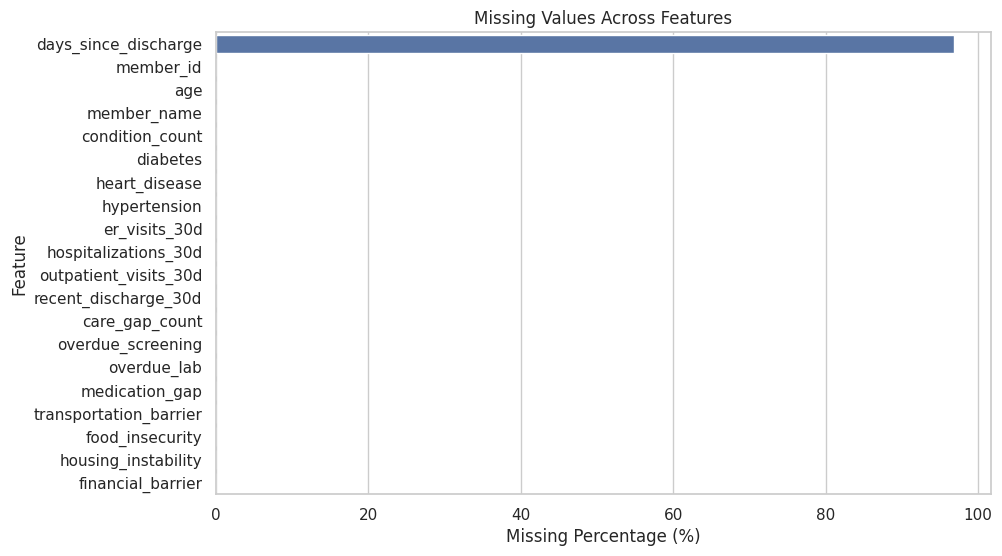

In [ ]:
# ============================================================
# STEP 10: VISUALIZE THE MISSING VALUES
# ============================================================

# I am plotting the missing-value percentage
# to quickly identify which features contain blanks.

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_values["Missing Percentage"],
    y=missing_values.index
)

plt.title("Missing Values Across Features")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")

plt.show()

In [ ]:
# ============================================================
# STEP 11: UNDERSTAND THE DISCHARGE MISSING VALUES
# ============================================================

# In this project, days_since_discharge can be blank intentionally.
# A blank value means that the member did not have a discharge
# during the last 30 days.

print(
    "Members without recent discharge:",
    (df["recent_discharge_30d"] == 0).sum()
)

print(
    "Blank days_since_discharge values:",
    df["days_since_discharge"].isna().sum()
)

Members without recent discharge: 9681
Blank days_since_discharge values: 9681


In [ ]:
# ============================================================
# STEP 12: CHECK FOR DUPLICATE RECORDS
# ============================================================

# Each row represents one member after the sheets were merged.
# I am checking whether any complete records were duplicated.

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [ ]:
# ============================================================
# STEP 13: CHECK FOR DUPLICATE MEMBER IDs
# ============================================================

# member_id should uniquely identify each member.
# Duplicate IDs could create problems during modeling.

print(
    "Duplicate member IDs:",
    df["member_id"].duplicated().sum()
)

Duplicate member IDs: 0


In [ ]:
# ============================================================
# STEP 14: CHECK UNIQUE VALUES
# ============================================================

# I am checking how many different values are present
# in every feature to understand the structure of the data.

unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values

,Unique Values
member_id,10000
member_name,600
age,68
condition_count,4
diabetes,2
hypertension,2
heart_disease,2
er_visits_30d,5
hospitalizations_30d,2
outpatient_visits_30d,11


In [ ]:
# ============================================================
# STEP 15: GET DESCRIPTIVE STATISTICS
# ============================================================

# I am using descriptive statistics to understand
# the range and distribution of the numerical features.

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.0,52.206900,16.343666,18.0,41.0,52.0,64.0,85.0
condition_count,10000.0,0.452800,0.620653,0.0,0.0,0.0,1.0,3.0
diabetes,10000.0,0.143700,0.350803,0.0,0.0,0.0,0.0,1.0
hypertension,10000.0,0.236400,0.424892,0.0,0.0,0.0,0.0,1.0
heart_disease,10000.0,0.072700,0.259656,0.0,0.0,0.0,0.0,1.0
er_visits_30d,10000.0,0.274400,0.541418,0.0,0.0,0.0,0.0,4.0
hospitalizations_30d,10000.0,0.033100,0.178907,0.0,0.0,0.0,0.0,1.0
outpatient_visits_30d,10000.0,1.806600,1.479802,0.0,1.0,2.0,3.0,10.0
recent_discharge_30d,10000.0,0.031900,0.175743,0.0,0.0,0.0,0.0,1.0
days_since_discharge,319.0,7.250784,6.950847,0.0,2.0,5.0,11.0,30.0


In [ ]:
# ============================================================
# STEP 16: IDENTIFY NUMERICAL FEATURES
# ============================================================

# These features represent quantities such as age,
# number of visits, condition count, and care-gap count.

numeric_features = [
    "age",
    "condition_count",
    "er_visits_30d",
    "hospitalizations_30d",
    "outpatient_visits_30d",
    "days_since_discharge",
    "care_gap_count"
]

In [ ]:
# ============================================================
# STEP 17: IDENTIFY BINARY FEATURES
# ============================================================

# These features represent whether a condition,
# care gap, discharge, or social-risk signal is present.

binary_features = [
    "diabetes",
    "hypertension",
    "heart_disease",
    "recent_discharge_30d",
    "overdue_screening",
    "overdue_lab",
    "medication_gap",
    "transportation_barrier",
    "food_insecurity",
    "housing_instability",
    "financial_barrier"
]

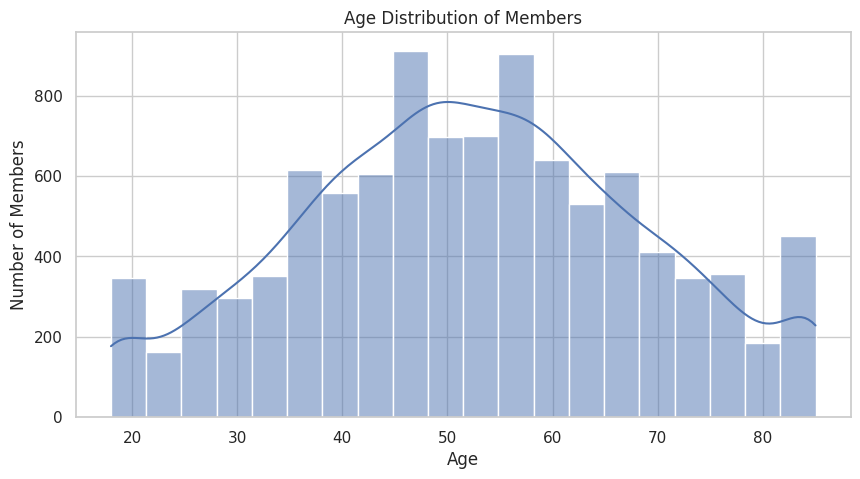

In [ ]:
# ============================================================
# STEP 18: ANALYZE AGE DISTRIBUTION
# ============================================================

# Age gives us the basic demographic profile of the
# synthetic member population.

plt.figure(figsize=(10, 5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution of Members")
plt.xlabel("Age")
plt.ylabel("Number of Members")

plt.show()

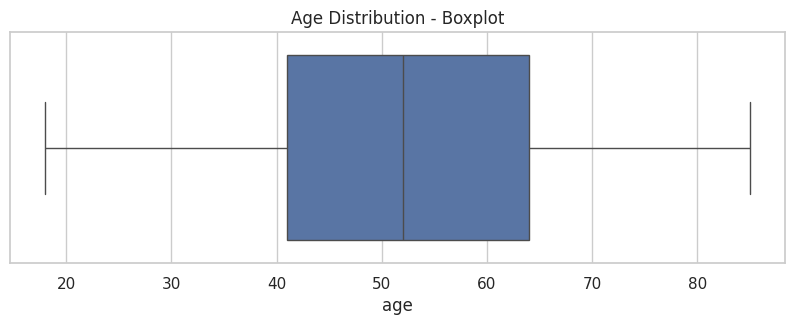

In [ ]:
# ============================================================
# STEP 19: CHECK AGE USING A BOXPLOT
# ============================================================

# I am using a boxplot to understand the spread of age
# and check for unusual age values.

plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df["age"]
)

plt.title("Age Distribution - Boxplot")

plt.show()

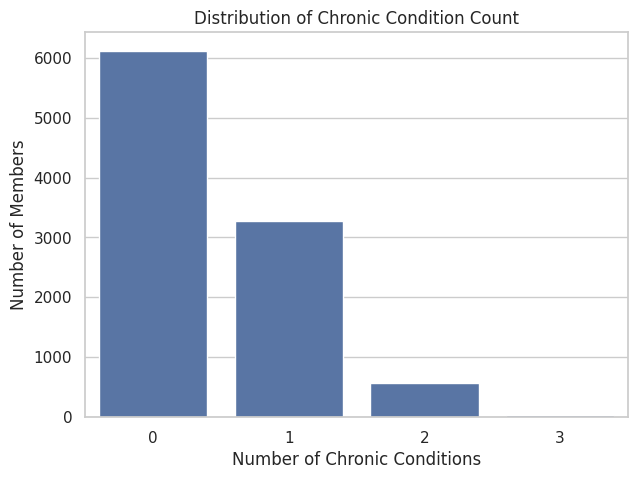

In [ ]:
# ============================================================
# STEP 20: ANALYZE CHRONIC CONDITION BURDEN
# ============================================================

# I want to understand how many chronic conditions
# each member has.

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="condition_count"
)

plt.title("Distribution of Chronic Condition Count")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Number of Members")

plt.show()

In [ ]:
# ============================================================
# STEP 21: CHECK INDIVIDUAL CONDITION PREVALENCE
# ============================================================

# I am checking how common diabetes, hypertension,
# and heart disease are in the member population.

condition_features = [
    "diabetes",
    "hypertension",
    "heart_disease"
]

condition_prevalence = (
    df[condition_features].mean() * 100
)

condition_prevalence.sort_values(
    ascending=False
)

,0
hypertension,23.64
diabetes,14.37
heart_disease,7.27


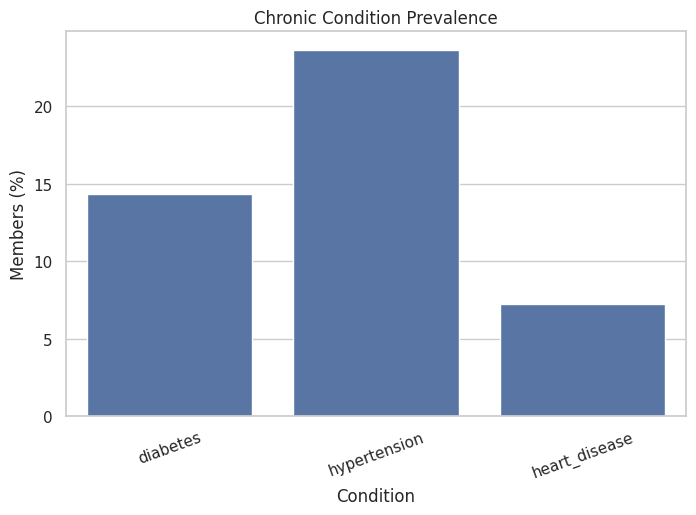

In [ ]:
# ============================================================
# STEP 22: VISUALIZE CONDITION PREVALENCE
# ============================================================

# This visualization makes it easier to compare
# the prevalence of the three chronic conditions.

plt.figure(figsize=(8, 5))

sns.barplot(
    x=condition_prevalence.index,
    y=condition_prevalence.values
)

plt.title("Chronic Condition Prevalence")
plt.xlabel("Condition")
plt.ylabel("Members (%)")

plt.xticks(rotation=20)

plt.show()

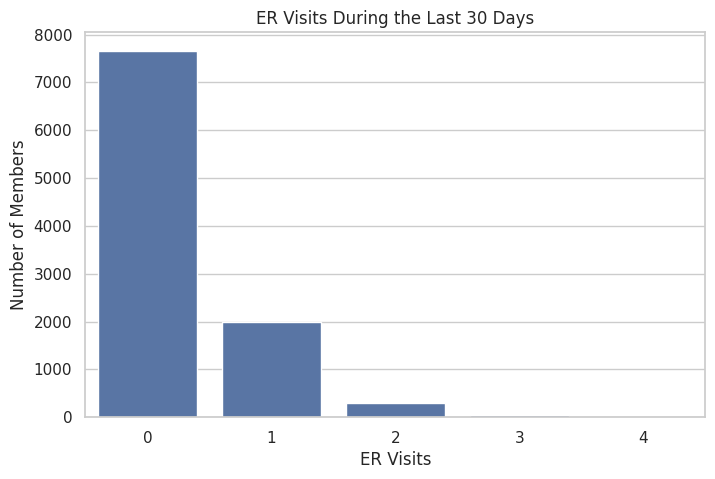

In [ ]:
# ============================================================
# STEP 23: ANALYZE ER UTILIZATION
# ============================================================

# Recent ER utilization is one of the important signals
# for identifying members who may need outreach.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="er_visits_30d"
)

plt.title("ER Visits During the Last 30 Days")
plt.xlabel("ER Visits")
plt.ylabel("Number of Members")

plt.show()

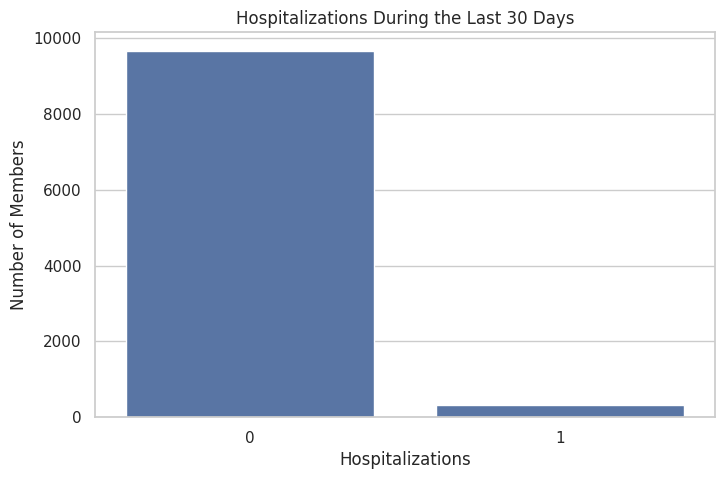

In [ ]:
# ============================================================
# STEP 24: ANALYZE HOSPITALIZATION
# ============================================================

# Hospitalization is a stronger acute-care signal,
# so I am checking the number of hospitalizations
# during the last 30 days.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="hospitalizations_30d"
)

plt.title("Hospitalizations During the Last 30 Days")
plt.xlabel("Hospitalizations")
plt.ylabel("Number of Members")

plt.show()

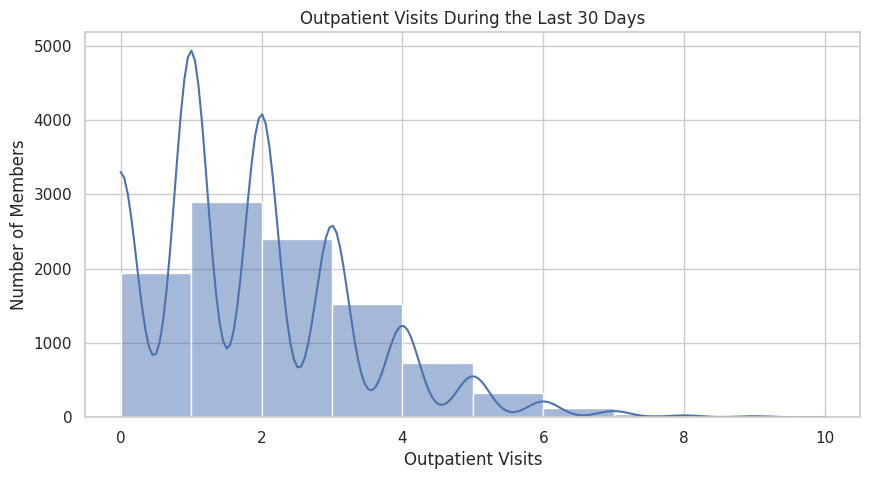

In [ ]:
# ============================================================
# STEP 25: ANALYZE OUTPATIENT UTILIZATION
# ============================================================

# Outpatient visits help me understand the broader
# healthcare utilization pattern during the last 30 days.

plt.figure(figsize=(10, 5))

sns.histplot(
    df["outpatient_visits_30d"],
    bins=10,
    kde=True
)

plt.title("Outpatient Visits During the Last 30 Days")
plt.xlabel("Outpatient Visits")
plt.ylabel("Number of Members")

plt.show()

In [ ]:
# ============================================================
# STEP 26: ANALYZE RECENT HOSPITAL DISCHARGE
# ============================================================

# Recent discharge is an important operational signal
# because recently discharged members may need timely follow-up.

discharge_counts = df[
    "recent_discharge_30d"
].value_counts()

print(discharge_counts)

recent_discharge_30d
0    9681
1     319
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 27: CALCULATE RECENT DISCHARGE PERCENTAGE
# ============================================================

# I am calculating the percentage of members
# discharged within the last 30 days.

recent_discharge_percentage = (
    df["recent_discharge_30d"].mean() * 100
)

print(
    f"Recent discharge percentage: "
    f"{recent_discharge_percentage:.2f}%"
)

Recent discharge percentage: 3.19%


In [ ]:
# ============================================================
# STEP 28: ANALYZE DAYS SINCE DISCHARGE
# ============================================================

# I am considering only members who actually had
# a recent discharge.

discharged_members = df[
    df["recent_discharge_30d"] == 1
].copy()

print(
    "Recently discharged members:",
    len(discharged_members)
)

Recently discharged members: 319


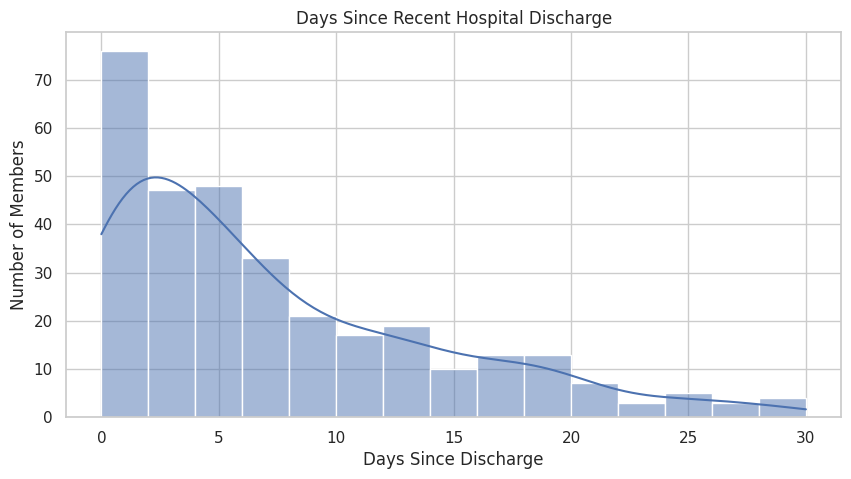

In [ ]:
# ============================================================
# STEP 29: VISUALIZE DAYS SINCE DISCHARGE
# ============================================================

# I am checking how recent the hospital discharges are
# within the 30-day period.

plt.figure(figsize=(10, 5))

sns.histplot(
    discharged_members["days_since_discharge"],
    bins=15,
    kde=True
)

plt.title("Days Since Recent Hospital Discharge")
plt.xlabel("Days Since Discharge")
plt.ylabel("Number of Members")

plt.show()

In [ ]:
# ============================================================
# STEP 30: IDENTIFY POST-DISCHARGE <24H MEMBERS
# ============================================================

# The dataset stores discharge recency at day-level granularity.
# I am using days_since_discharge = 0 as an operational proxy
# for members discharged within the most recent 24-hour period.

df["post_discharge_24h"] = (
    (df["recent_discharge_30d"] == 1)
    &
    (df["days_since_discharge"] == 0)
).astype(int)

print(
    "Post-discharge <24h members (operational proxy):",
    df["post_discharge_24h"].sum()
)
df["post_discharge_24h"] = (
    (df["recent_discharge_30d"] == 1)
    &
    (df["days_since_discharge"] == 0)
).astype(int)

print(
    "Post-discharge <24h members:",
    df["post_discharge_24h"].sum()
)

Post-discharge <24h members (operational proxy): 32
Post-discharge <24h members: 32


In [ ]:
# ============================================================
# STEP 31: CALCULATE POST-DISCHARGE <24H PERCENTAGE
# ============================================================

# I am calculating how large this very-recent discharge
# group is within the complete member population.

post_24h_percentage = (
    df["post_discharge_24h"].mean() * 100
)

print(
    f"Post-discharge <24h percentage: "
    f"{post_24h_percentage:.2f}%"
)

Post-discharge <24h percentage: 0.32%


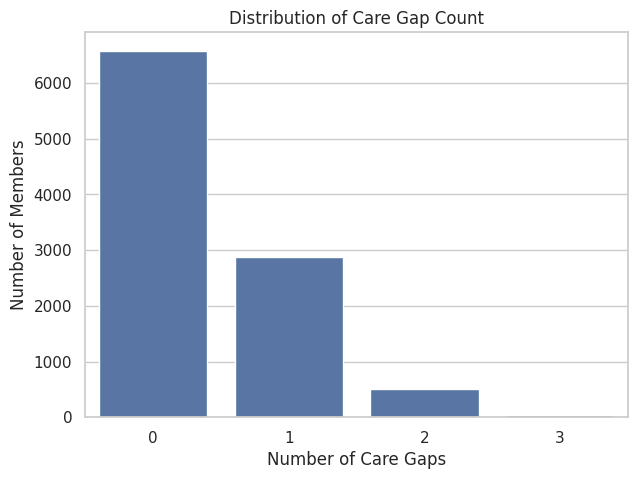

In [ ]:
# ============================================================
# STEP 32: ANALYZE CARE GAP COUNT
# ============================================================

# Care gaps represent unresolved care needs.
# I am checking how many gaps members have.

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="care_gap_count"
)

plt.title("Distribution of Care Gap Count")
plt.xlabel("Number of Care Gaps")
plt.ylabel("Number of Members")

plt.show()

In [ ]:
# ============================================================
# STEP 33: CHECK INDIVIDUAL CARE GAP PREVALENCE
# ============================================================

# I am checking the prevalence of each major care gap
# separately.

care_gap_features = [
    "overdue_screening",
    "overdue_lab",
    "medication_gap"
]

care_gap_prevalence = (
    df[care_gap_features].mean() * 100
)

care_gap_prevalence

,0
overdue_screening,15.76
overdue_lab,12.10
medication_gap,12.08


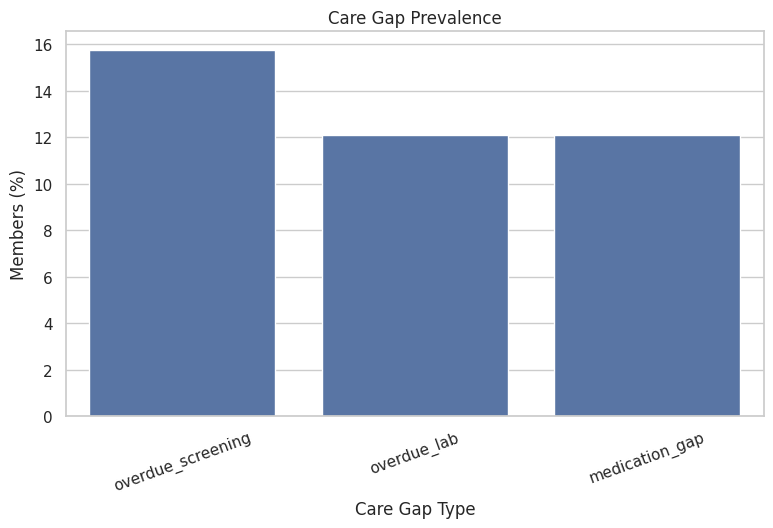

In [ ]:
# ============================================================
# STEP 34: VISUALIZE CARE GAP PREVALENCE
# ============================================================

# This helps me compare which types of care gaps
# occur most frequently.

plt.figure(figsize=(9, 5))

sns.barplot(
    x=care_gap_prevalence.index,
    y=care_gap_prevalence.values
)

plt.title("Care Gap Prevalence")
plt.xlabel("Care Gap Type")
plt.ylabel("Members (%)")

plt.xticks(rotation=20)

plt.show()

In [ ]:
# ============================================================
# STEP 35: ANALYZE SOCIAL-RISK SIGNALS
# ============================================================

# Social barriers can affect a member's ability
# to access and follow recommended care.

social_features = [
    "transportation_barrier",
    "food_insecurity",
    "housing_instability",
    "financial_barrier"
]

social_prevalence = (
    df[social_features].mean() * 100
)

social_prevalence

,0
transportation_barrier,10.24
food_insecurity,10.01
housing_instability,5.39
financial_barrier,11.96


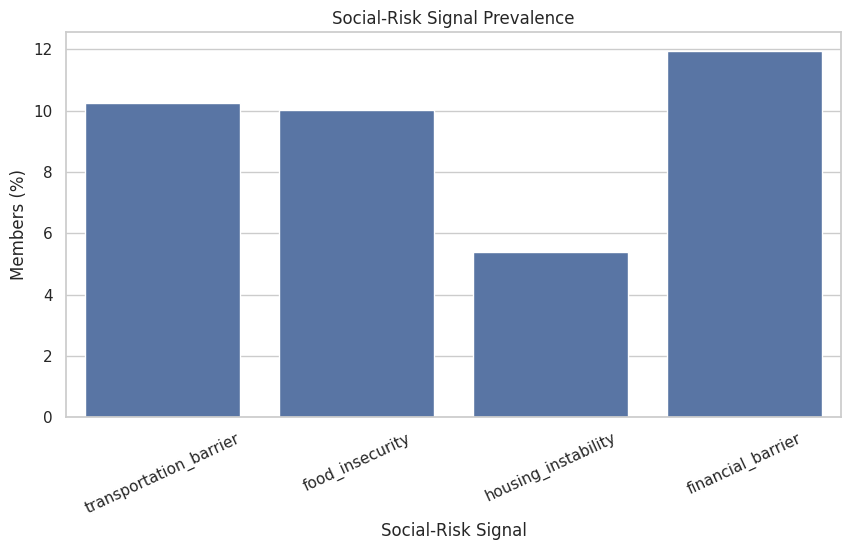

In [ ]:
# ============================================================
# STEP 36: VISUALIZE SOCIAL-RISK PREVALENCE
# ============================================================

# I am comparing the different social-risk signals
# across the member population.

plt.figure(figsize=(10, 5))

sns.barplot(
    x=social_prevalence.index,
    y=social_prevalence.values
)

plt.title("Social-Risk Signal Prevalence")
plt.xlabel("Social-Risk Signal")
plt.ylabel("Members (%)")

plt.xticks(rotation=25)

plt.show()

In [ ]:
# ============================================================
# STEP 37: CREATE A TEMPORARY SOCIAL-RISK COUNT
# ============================================================

# I am combining the individual social-risk indicators
# into a temporary count so that I can study overall
# social-risk burden.

df["social_risk_count"] = df[
    social_features
].sum(axis=1)

df["social_risk_count"].value_counts().sort_index()

,count
social_risk_count,
0,7215
1,1899
2,798
3,87
4,1


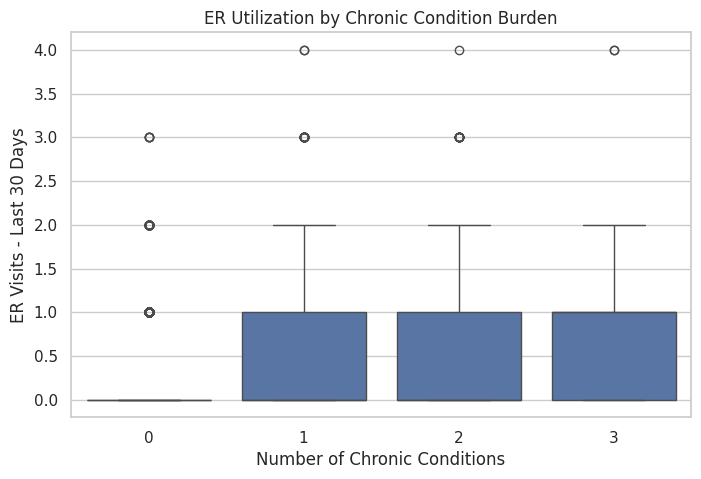

In [ ]:
# ============================================================
# STEP 38: CHECK CONDITION BURDEN VS ER UTILIZATION
# ============================================================

# I want to see whether members with more chronic conditions
# show different levels of recent ER utilization.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="condition_count",
    y="er_visits_30d"
)

plt.title(
    "ER Utilization by Chronic Condition Burden"
)

plt.xlabel("Number of Chronic Conditions")
plt.ylabel("ER Visits - Last 30 Days")

plt.show()

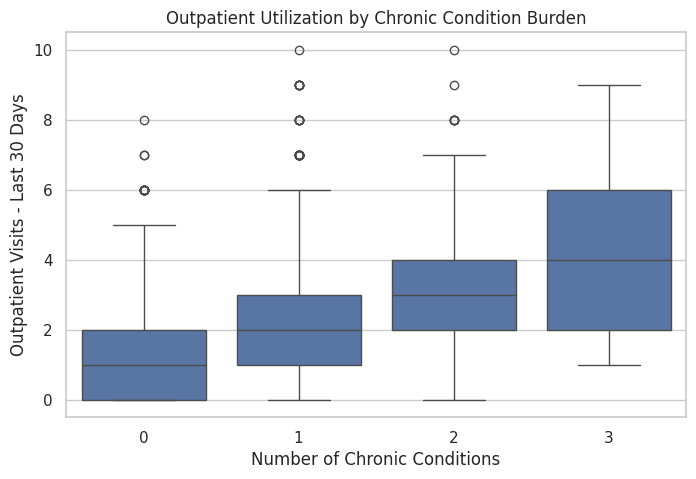

In [ ]:
# ============================================================
# STEP 39: CHECK CONDITION BURDEN VS OUTPATIENT UTILIZATION
# ============================================================

# I am checking whether outpatient utilization also
# changes with the number of chronic conditions.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="condition_count",
    y="outpatient_visits_30d"
)

plt.title(
    "Outpatient Utilization by Chronic Condition Burden"
)

plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Outpatient Visits - Last 30 Days")

plt.show()

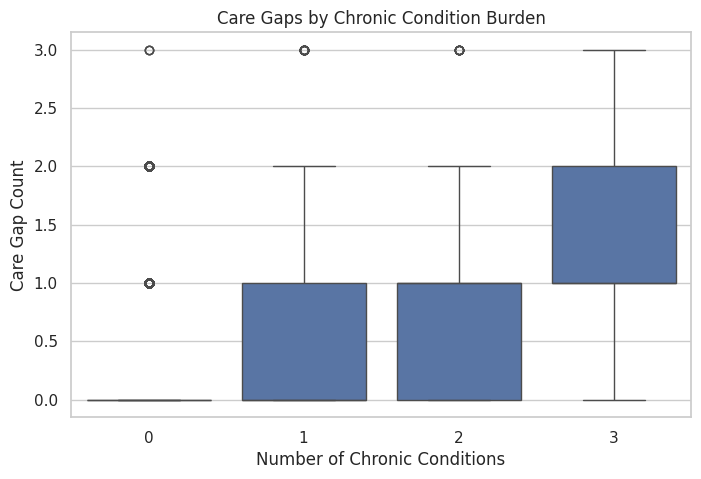

In [ ]:
# ============================================================
# STEP 40: CHECK CONDITION BURDEN VS CARE GAPS
# ============================================================

# I am checking whether members with more chronic conditions
# also tend to have more unresolved care gaps.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="condition_count",
    y="care_gap_count"
)

plt.title(
    "Care Gaps by Chronic Condition Burden"
)

plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Care Gap Count")

plt.show()

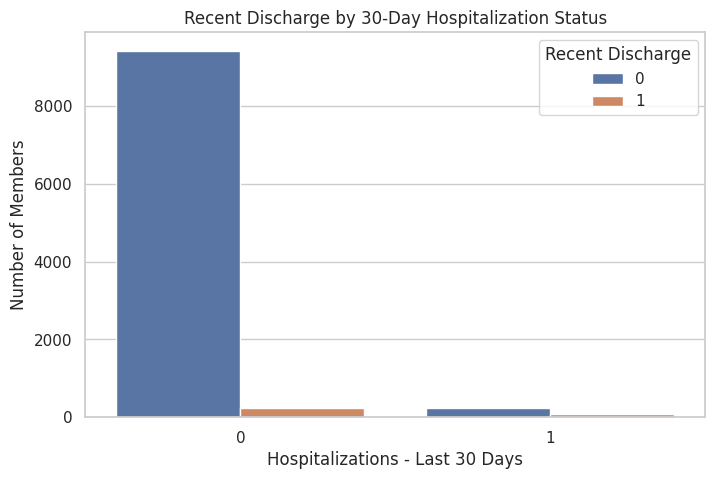

In [ ]:
# ============================================================
# STEP 41: CHECK HOSPITALIZATION VS RECENT DISCHARGE
# ============================================================

# A recent hospitalization should be related to a recent
# discharge signal, so I am checking these two features together.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="hospitalizations_30d",
    hue="recent_discharge_30d"
)

plt.title(
    "Recent Discharge by 30-Day Hospitalization Status"
)

plt.xlabel("Hospitalizations - Last 30 Days")
plt.ylabel("Number of Members")

plt.legend(
    title="Recent Discharge"
)

plt.show()

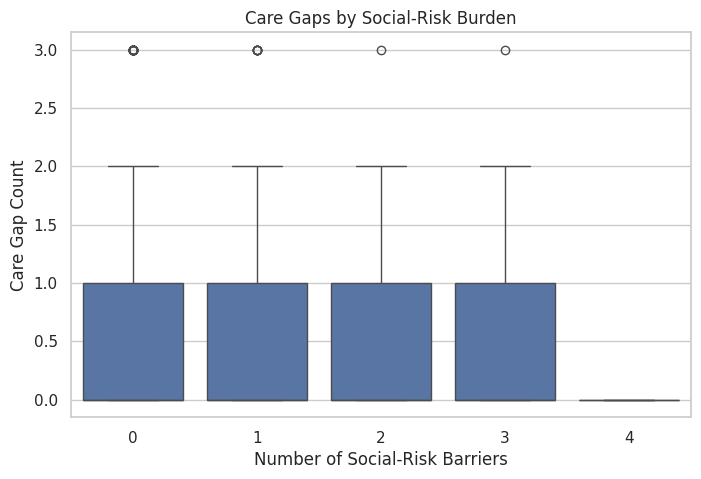

In [ ]:
# ============================================================
# STEP 42: CHECK SOCIAL RISK VS CARE GAPS
# ============================================================

# I am checking whether members with more social barriers
# have a different distribution of care gaps.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="social_risk_count",
    y="care_gap_count"
)

plt.title(
    "Care Gaps by Social-Risk Burden"
)

plt.xlabel("Number of Social-Risk Barriers")
plt.ylabel("Care Gap Count")

plt.show()

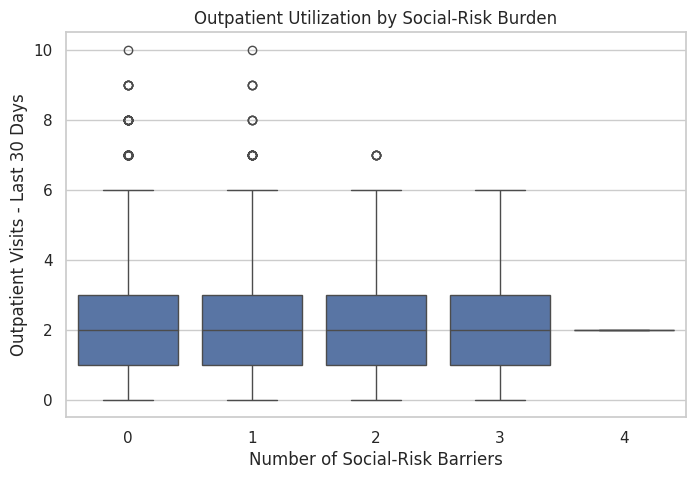

In [ ]:
# ============================================================
# STEP 43: CHECK SOCIAL RISK VS UTILIZATION
# ============================================================

# I am checking whether social-risk burden is associated
# with differences in recent outpatient utilization.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="social_risk_count",
    y="outpatient_visits_30d"
)

plt.title(
    "Outpatient Utilization by Social-Risk Burden"
)

plt.xlabel("Number of Social-Risk Barriers")
plt.ylabel("Outpatient Visits - Last 30 Days")

plt.show()

In [ ]:
# ============================================================
# STEP 44: PREPARE FEATURES FOR CORRELATION ANALYSIS
# ============================================================

# I am selecting the main numerical and derived signals
# to understand how they relate to one another.

correlation_features = [
    "age",
    "condition_count",
    "er_visits_30d",
    "hospitalizations_30d",
    "outpatient_visits_30d",
    "care_gap_count",
    "social_risk_count",
    "recent_discharge_30d",
    "post_discharge_24h"
]

correlation_matrix = df[
    correlation_features
].corr()

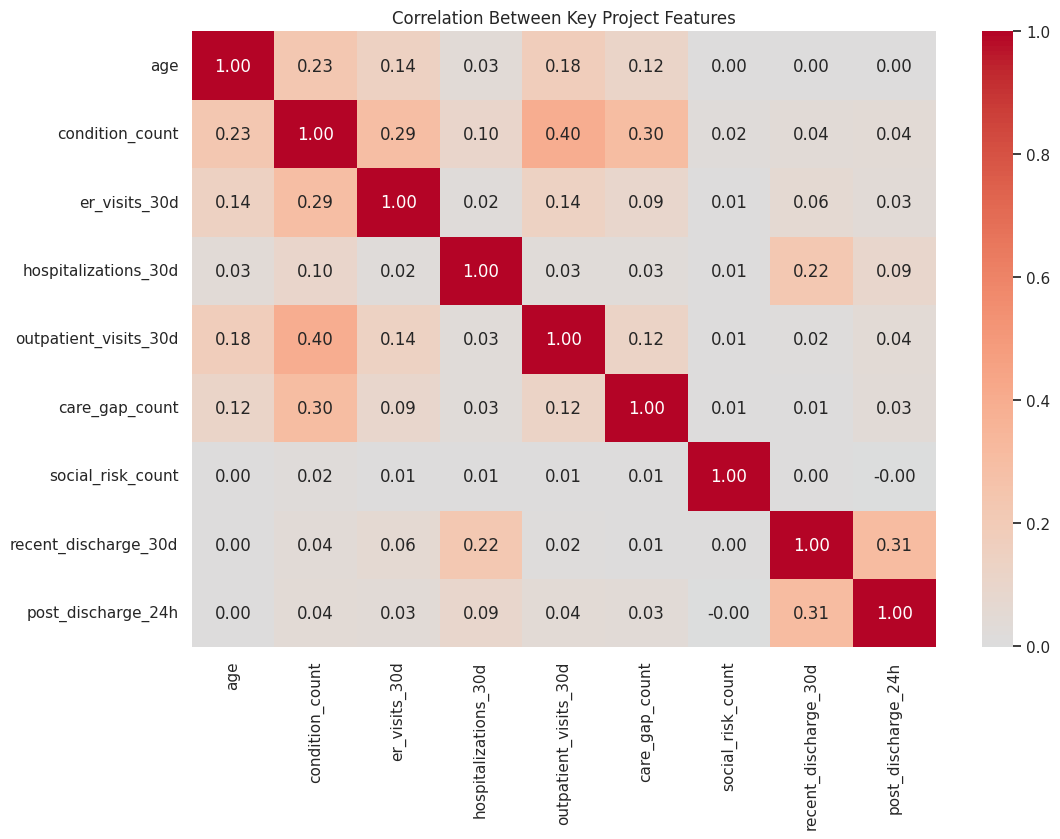

In [ ]:
# ============================================================
# STEP 45: VISUALIZE THE CORRELATION MATRIX
# ============================================================

# The heatmap gives me an overall view of relationships
# between the main project signals.

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Key Project Features")

plt.show()

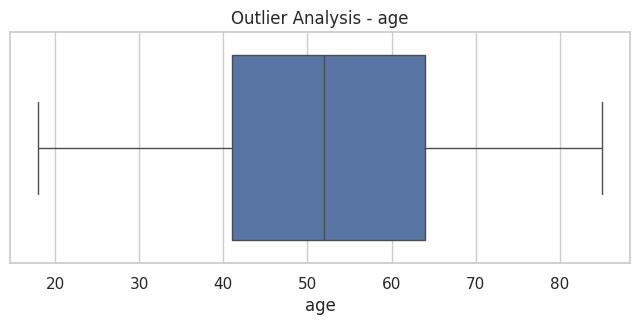

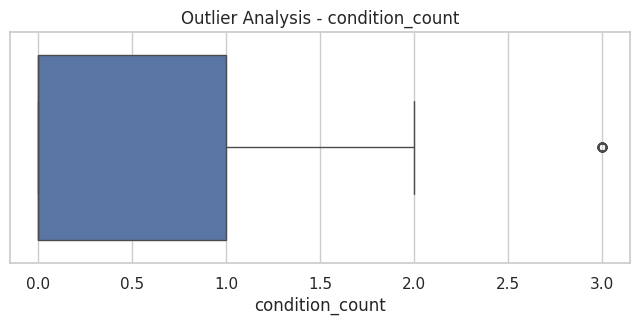

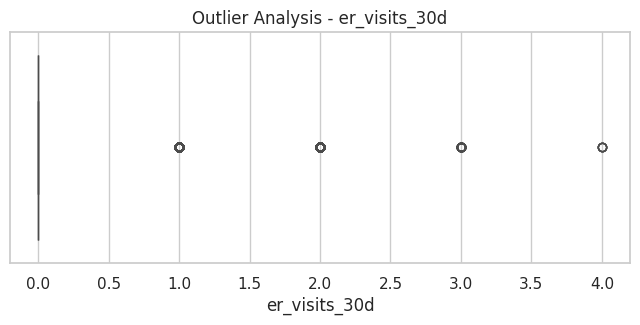

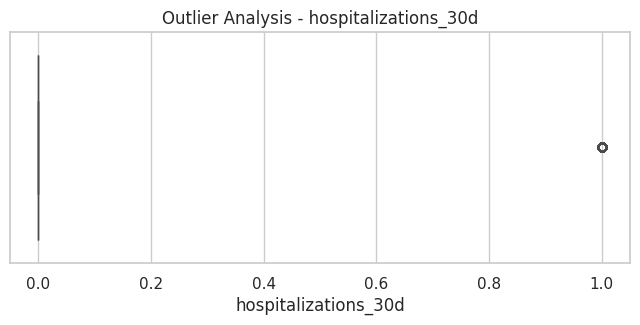

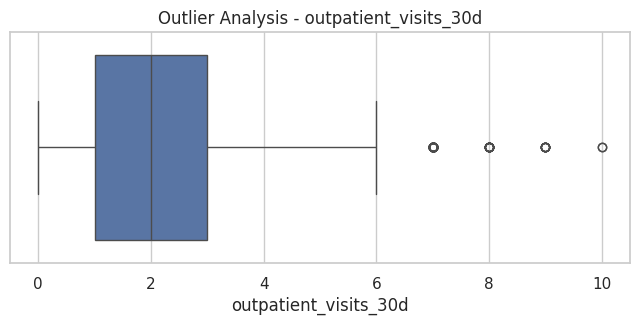

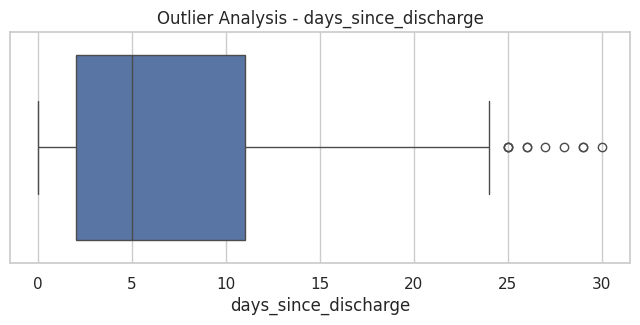

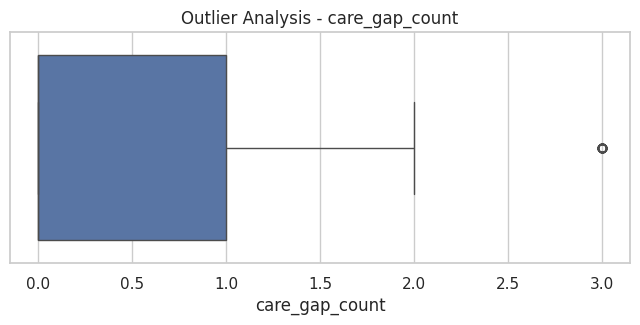

In [ ]:
# ============================================================
# STEP 46: CHECK POSSIBLE OUTLIERS
# ============================================================

# I am checking the numerical features for unusual values.
# I will not automatically remove them because high utilization
# may actually represent the members we want to prioritize.

for column in numeric_features:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=df[column]
    )

    plt.title(
        f"Outlier Analysis - {column}"
    )

    plt.show()

In [ ]:
# ============================================================
# STEP 47: CREATE A NUMERICAL SUMMARY TABLE
# ============================================================

# I am creating one summary table so that I can review
# the main numerical characteristics together.

summary = pd.DataFrame({
    "Mean": df[numeric_features].mean(),
    "Median": df[numeric_features].median(),
    "Standard Deviation": df[numeric_features].std(),
    "Minimum": df[numeric_features].min(),
    "Maximum": df[numeric_features].max()
})

summary

,Mean,Median,Standard Deviation,Minimum,Maximum
age,52.206900,52.0,16.343666,18.0,85.0
condition_count,0.452800,0.0,0.620653,0.0,3.0
er_visits_30d,0.274400,0.0,0.541418,0.0,4.0
hospitalizations_30d,0.033100,0.0,0.178907,0.0,1.0
outpatient_visits_30d,1.806600,2.0,1.479802,0.0,10.0
days_since_discharge,7.250784,5.0,6.950847,0.0,30.0
care_gap_count,0.399400,0.0,0.602259,0.0,3.0


In [ ]:
# ============================================================
# STEP 48: CREATE A PROJECT-LEVEL EDA SUMMARY
# ============================================================

# I am collecting the main project indicators in one table.
# This will make it easier to refer to the findings later
# when building the prioritization model.

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Members",
        "Average Age",
        "Members with Diabetes",
        "Members with Hypertension",
        "Members with Heart Disease",
        "Recent Discharge - 30 Days",
        "Post-Discharge <24h",
        "Members with At Least One Care Gap",
        "Transportation Barrier",
        "Food Insecurity",
        "Housing Instability",
        "Financial Barrier"
    ],

    "Value": [
        len(df),
        round(df["age"].mean(), 2),
        df["diabetes"].sum(),
        df["hypertension"].sum(),
        df["heart_disease"].sum(),
        df["recent_discharge_30d"].sum(),
        df["post_discharge_24h"].sum(),
        (df["care_gap_count"] > 0).sum(),
        df["transportation_barrier"].sum(),
        df["food_insecurity"].sum(),
        df["housing_instability"].sum(),
        df["financial_barrier"].sum()
    ]
})

eda_summary

,Metric,Value
0,Total Members,10000.00
1,Average Age,52.21
2,Members with Diabetes,1437.00
3,Members with Hypertension,2364.00
4,Members with Heart Disease,727.00
5,Recent Discharge - 30 Days,319.00
6,Post-Discharge <24h,32.00
7,Members with At Least One Care Gap,3418.00
8,Transportation Barrier,1024.00
9,Food Insecurity,1001.00


In [ ]:
# ============================================================
# STEP 49: SAVE THE EDA VERSION OF THE DATASET
# ============================================================

# I am saving the dataset after creating the temporary
# analysis features so that the work can be reused
# in the next stage.

df.to_csv(
    "eda_processed_dataset.csv",
    index=False
)

print("EDA dataset saved successfully.")

EDA dataset saved successfully.


In [ ]:
# ============================================================
# STEP 50: FINAL EDA CHECK
# ============================================================

# Before finishing EDA, I am checking the final shape
# and making sure the dataset is still at the member level.

print("Final EDA dataset shape:", df.shape)

print(
    "Unique members:",
    df["member_id"].nunique()
)

print(
    "Duplicate member IDs:",
    df["member_id"].duplicated().sum()
)

Final EDA dataset shape: (10000, 22)
Unique members: 10000
Duplicate member IDs: 0


# EDA CONCLUSION

The exploratory data analysis was performed to understand the
member population and the major signals required for the
Care Management Outreach Prioritization Assistant.

The analysis covered:

- Member age distribution
- Chronic-condition burden
- Recent 30-day healthcare utilization
- Recent hospital discharge
- Post-discharge <24h members
- Care gaps
- Social-risk indicators
- Relationships between major features
- Correlation analysis
- Possible outliers

The EDA results will be used to guide the next stage of
feature engineering and development of the prioritization model.

The analysis confirms that the dataset contains variation across
clinical burden, recent utilization, discharge recency, care gaps,
and social-risk signals, making these suitable candidate inputs
for the subsequent prioritization model.

No final priority label or priority score was created during
EDA. The target definition will be finalized before model
training.

**FEATURE ENGINEERING**

The official use case says the assistant should rank members using recent utilization, conditions, care gaps, and social-risk signals, then provide an outreach rationale and next-best action for human review.

We will not train CatBoost yet. First we'll create a clean model-ready dataset.

In [ ]:
# ============================================================
# STEP 51: START FEATURE ENGINEERING
# ============================================================

# The EDA is now completed.
# I am creating a separate model-ready dataset so that
# the original merged dataset remains unchanged.

model_df = df.copy()

print("Feature engineering started.")
print("Current dataset shape:", model_df.shape)

Feature engineering started.
Current dataset shape: (10000, 22)


In [ ]:
# ============================================================
# STEP 52: SEPARATE MEMBER IDENTIFIERS FROM MODEL FEATURES
# ============================================================

# member_id and member_name are useful for identifying members
# in the final application, but they should not be given to
# the machine learning model because they do not represent
# healthcare characteristics.

member_identifiers = [
    "member_id",
    "member_name"
]

model_features_df = model_df.drop(
    columns=member_identifiers
)

print("Identifier columns excluded from model features:")
print(member_identifiers)

print("\nModel feature shape:", model_features_df.shape)

Identifier columns excluded from model features:
['member_id', 'member_name']

Model feature shape: (10000, 20)


In [ ]:
# ============================================================
# STEP 53: CREATE THE POST-DISCHARGE <24H OPERATIONAL SIGNAL
# ============================================================

# The dataset stores discharge timing at day-level granularity.
# Therefore, days_since_discharge = 0 is used as an operational
# proxy for the most recent post-discharge period.

model_df["post_discharge_24h"] = (
    (model_df["recent_discharge_30d"] == 1)
    &
    (model_df["days_since_discharge"] == 0)
).astype(int)

print(
    "Post-discharge <24h operational proxy:",
    model_df["post_discharge_24h"].sum()
)

Post-discharge <24h operational proxy: 32


In [ ]:
# ============================================================
# STEP 54: CREATE TOTAL 30-DAY UTILIZATION
# ============================================================

# I am combining the three recent utilization measures
# to get an overall view of healthcare activity during
# the last 30 days.

model_df["total_utilization_30d"] = (
    model_df["er_visits_30d"]
    + model_df["hospitalizations_30d"]
    + model_df["outpatient_visits_30d"]
)

print(
    model_df[
        [
            "er_visits_30d",
            "hospitalizations_30d",
            "outpatient_visits_30d",
            "total_utilization_30d"
        ]
    ].head()
)

   er_visits_30d  hospitalizations_30d  outpatient_visits_30d  \
0              0                     0                      2   
1              0                     0                      2   
2              1                     0                      2   
3              0                     0                      0   
4              0                     0                      1   

   total_utilization_30d  
0                      2  
1                      2  
2                      3  
3                      0  
4                      1  


In [ ]:
# ============================================================
# STEP 55: CREATE ACUTE UTILIZATION
# ============================================================

# ER visits and hospitalizations represent more acute
# healthcare utilization than routine outpatient visits.
# I am combining them into one feature for the model.

model_df["acute_utilization_30d"] = (
    model_df["er_visits_30d"]
    + model_df["hospitalizations_30d"]
)

print(
    model_df[
        [
            "er_visits_30d",
            "hospitalizations_30d",
            "acute_utilization_30d"
        ]
    ].head()
)

   er_visits_30d  hospitalizations_30d  acute_utilization_30d
0              0                     0                      0
1              0                     0                      0
2              1                     0                      1
3              0                     0                      0
4              0                     0                      0


In [ ]:
# ============================================================
# STEP 56: CREATE OVERALL SOCIAL-RISK BURDEN
# ============================================================

# Instead of looking at only one social barrier,
# I am counting how many different social-risk barriers
# are present for each member.

social_risk_features = [
    "transportation_barrier",
    "food_insecurity",
    "housing_instability",
    "financial_barrier"
]

model_df["social_risk_count"] = (
    model_df[social_risk_features]
    .sum(axis=1)
)

print(
    model_df[
        social_risk_features + ["social_risk_count"]
    ].head()
)

   transportation_barrier  food_insecurity  housing_instability  \
0                       0                0                    0   
1                       1                0                    0   
2                       1                0                    0   
3                       0                0                    0   
4                       0                0                    0   

   financial_barrier  social_risk_count  
0                  0                  0  
1                  0                  1  
2                  1                  2  
3                  0                  0  
4                  0                  0  


In [ ]:
# ============================================================
# STEP 57: CREATE CLINICAL BURDEN FEATURE
# ============================================================

# condition_count already represents the number of chronic
# conditions. I am creating a clearly named feature so that
# its role is obvious in the model pipeline.

model_df["clinical_burden"] = (
    model_df["condition_count"]
)

print(
    model_df[
        [
            "condition_count",
            "clinical_burden"
        ]
    ].head()
)

   condition_count  clinical_burden
0                0                0
1                1                1
2                2                2
3                0                0
4                0                0


In [ ]:
# ============================================================
# STEP 58: CREATE CARE-GAP BURDEN
# ============================================================

# care_gap_count already represents the number of unresolved
# care gaps. I am keeping a separate model feature with a
# descriptive name.

model_df["care_gap_burden"] = (
    model_df["care_gap_count"]
)

print(
    model_df[
        [
            "care_gap_count",
            "care_gap_burden"
        ]
    ].head()
)

   care_gap_count  care_gap_burden
0               0                0
1               0                0
2               1                1
3               0                0
4               0                0


In [ ]:
# ============================================================
# STEP 59: CREATE DISCHARGE RECENCY FEATURE
# ============================================================

# A recently discharged member may need more timely outreach.
# I am creating a simple recency value where a smaller number
# of days since discharge represents a more recent event.

# For members without a recent discharge, the value is kept
# as missing because discharge recency does not apply to them.

model_df["discharge_recency"] = (
    model_df["days_since_discharge"]
)

print(
    model_df[
        [
            "recent_discharge_30d",
            "days_since_discharge",
            "discharge_recency"
        ]
    ].head(10)
)

   recent_discharge_30d  days_since_discharge  discharge_recency
0                     0                   NaN                NaN
1                     0                   NaN                NaN
2                     0                   NaN                NaN
3                     0                   NaN                NaN
4                     0                   NaN                NaN
5                     0                   NaN                NaN
6                     0                   NaN                NaN
7                     0                   NaN                NaN
8                     0                   NaN                NaN
9                     0                   NaN                NaN


In [ ]:
# ============================================================
# STEP 60: REVIEW THE ENGINEERED FEATURES
# ============================================================

# I am checking the new features together before deciding
# which ones should finally be given to CatBoost.

engineered_features = [
    "clinical_burden",
    "total_utilization_30d",
    "acute_utilization_30d",
    "care_gap_burden",
    "social_risk_count",
    "recent_discharge_30d",
    "post_discharge_24h",
    "discharge_recency"
]

model_df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
clinical_burden,10000.0,0.452800,0.620653,0.0,0.0,0.0,1.0,3.0
total_utilization_30d,10000.0,2.114100,1.661673,0.0,1.0,2.0,3.0,11.0
acute_utilization_30d,10000.0,0.307500,0.573565,0.0,0.0,0.0,1.0,4.0
care_gap_burden,10000.0,0.399400,0.602259,0.0,0.0,0.0,1.0,3.0
social_risk_count,10000.0,0.376000,0.669081,0.0,0.0,0.0,1.0,4.0
recent_discharge_30d,10000.0,0.031900,0.175743,0.0,0.0,0.0,0.0,1.0
post_discharge_24h,10000.0,0.003200,0.056481,0.0,0.0,0.0,0.0,1.0
discharge_recency,319.0,7.250784,6.950847,0.0,2.0,5.0,11.0,30.0


In [ ]:
# ============================================================
# STEP 61: VALIDATE THE ENGINEERED FEATURES
# ============================================================

# Before using these features for machine learning,
# I am checking that the derived values are consistent
# with the original columns.

print(
    "Clinical burden matches condition count:",
    (
        model_df["clinical_burden"]
        == model_df["condition_count"]
    ).all()
)

print(
    "Care-gap burden matches care-gap count:",
    (
        model_df["care_gap_burden"]
        == model_df["care_gap_count"]
    ).all()
)

print(
    "Social-risk count range:",
    model_df["social_risk_count"].min(),
    "to",
    model_df["social_risk_count"].max()
)

print(
    "Total utilization range:",
    model_df["total_utilization_30d"].min(),
    "to",
    model_df["total_utilization_30d"].max()
)

Clinical burden matches condition count: True
Care-gap burden matches care-gap count: True
Social-risk count range: 0 to 4
Total utilization range: 0 to 11


In [ ]:
# ============================================================
# STEP 62: VALIDATE DISCHARGE FEATURE LOGIC
# ============================================================

# I am checking whether the recent-discharge flag and
# discharge timing are logically consistent.

invalid_discharge_records = model_df[
    (
        (model_df["recent_discharge_30d"] == 0)
        &
        (model_df["days_since_discharge"].notna())
    )
    |
    (
        (model_df["recent_discharge_30d"] == 1)
        &
        (model_df["days_since_discharge"].isna())
    )
]

print(
    "Invalid discharge records:",
    len(invalid_discharge_records)
)

Invalid discharge records: 0


In [ ]:
# ============================================================
# STEP 63: VALIDATE POST-DISCHARGE <24H LOGIC
# ============================================================

# I am checking that every post-discharge <24h member
# actually has a recent discharge and day 0 discharge recency.

invalid_24h_records = model_df[
    (
        model_df["post_discharge_24h"] == 1
    )
    &
    (
        ~(
            (model_df["recent_discharge_30d"] == 1)
            &
            (model_df["days_since_discharge"] == 0)
        )
    )
]

print(
    "Invalid post-discharge <24h records:",
    len(invalid_24h_records)
)

Invalid post-discharge <24h records: 0


In [ ]:
# ============================================================
# STEP 64: DEFINE THE INITIAL MODEL FEATURE SET
# ============================================================

# I am selecting features that represent the major signal
# groups identified in the project requirements:
#
# 1. Member characteristics
# 2. Clinical conditions
# 3. Recent utilization
# 4. Recent discharge
# 5. Care gaps
# 6. Social-risk signals

model_features = [
    # Member characteristics
    "age",

    # Clinical conditions
    "condition_count",
    "diabetes",
    "hypertension",
    "heart_disease",

    # Recent utilization
    "er_visits_30d",
    "hospitalizations_30d",
    "outpatient_visits_30d",
    "total_utilization_30d",
    "acute_utilization_30d",

    # Recent discharge
    "recent_discharge_30d",
    "days_since_discharge",
    "post_discharge_24h",

    # Care gaps
    "care_gap_count",
    "overdue_screening",
    "overdue_lab",
    "medication_gap",

    # Social risk
    "transportation_barrier",
    "food_insecurity",
    "housing_instability",
    "financial_barrier",
    "social_risk_count"
]

print("Number of candidate model features:", len(model_features))

Number of candidate model features: 22


In [ ]:
# ============================================================
# STEP 65: CREATE THE MODEL INPUT DATAFRAME
# ============================================================

# I am creating a separate dataframe containing only
# the candidate features that can be used by the model.

X_features = model_df[model_features].copy()

print("Model input shape:", X_features.shape)

X_features.head()

Model input shape: (10000, 22)


,age,condition_count,diabetes,hypertension,heart_disease,er_visits_30d,hospitalizations_30d,outpatient_visits_30d,total_utilization_30d,acute_utilization_30d,...,post_discharge_24h,care_gap_count,overdue_screening,overdue_lab,medication_gap,transportation_barrier,food_insecurity,housing_instability,financial_barrier,social_risk_count
0,20,0,0,0,0,0,0,2,2,0,...,0,0,0,0,0,0,0,0,0,0
1,71,1,1,0,0,0,0,2,2,0,...,0,0,0,0,0,1,0,0,0,1
2,72,2,1,1,0,1,0,2,3,1,...,0,1,0,1,0,1,0,0,1,2
3,44,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,61,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ============================================================
# STEP 66: CREATE THE SYNTHETIC OUTREACH-NEED TARGET
# ============================================================

# Our synthetic dataset does not contain a historical outcome
# showing whether a member actually required care-management
# outreach.
#
# Therefore, I am creating a synthetic outreach-need outcome
# for the ML experimentation stage.
#
# The target is based on the healthcare signals identified
# during EDA, with controlled variation so that the model
# has a meaningful prediction task.
#
# This target represents outreach need in the synthetic
# prototype and is NOT a real clinical outcome.


# I am creating an underlying outreach-need signal from
# the major project factors.

outreach_signal = (
    0.10 * model_df["age"].fillna(model_df["age"].median())
    / 85

    + 0.18 * (
        model_df["condition_count"] / 3
    )

    + 0.18 * (
        model_df["acute_utilization_30d"] / 5
    )

    + 0.18 * (
        model_df["care_gap_count"] / 3
    )

    + 0.12 * (
        model_df["social_risk_count"] / 4
    )

    + 0.16 * model_df["recent_discharge_30d"]

    + 0.08 * model_df["post_discharge_24h"]
)


# I am adding a small amount of random variation so that
# the target is not simply a fixed deterministic formula.

rng = np.random.default_rng(42)

outreach_signal = (
    outreach_signal
    + rng.normal(
        loc=0,
        scale=0.08,
        size=len(model_df)
    )
)


# I am using the upper part of the signal distribution
# to create the members who require outreach in this
# synthetic modeling experiment.

target_threshold = np.quantile(
    outreach_signal,
    0.75
)

model_df["outreach_need"] = (
    outreach_signal >= target_threshold
).astype(int)

print("Synthetic outreach target created.")

Synthetic outreach target created.


In [ ]:
# ============================================================
# STEP 67: CHECK THE OUTREACH-NEED TARGET DISTRIBUTION
# ============================================================

# Before training any model, I am checking how many members
# belong to each target class.

target_counts = model_df[
    "outreach_need"
].value_counts().sort_index()

print(target_counts)




# I am also checking the percentage of members in each class
# because an extremely imbalanced target can make model
# evaluation misleading.

target_percentage = (
    model_df["outreach_need"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nTarget distribution (%):")
print(target_percentage)

outreach_need
0    7500
1    2500
Name: count, dtype: int64

Target distribution (%):
outreach_need
0    75.0
1    25.0
Name: proportion, dtype: float64


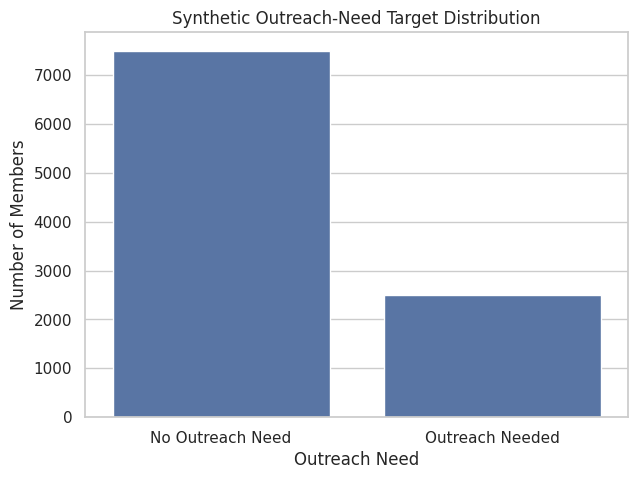

In [ ]:
# ============================================================
# STEP 68: VISUALIZE THE OUTREACH-NEED TARGET
# ============================================================

# I am visualizing the target distribution to make sure
# both classes are represented clearly before model training.

plt.figure(figsize=(7, 5))

sns.countplot(
    data=model_df,
    x="outreach_need"
)

plt.title("Synthetic Outreach-Need Target Distribution")
plt.xlabel("Outreach Need")
plt.ylabel("Number of Members")

plt.xticks(
    [0, 1],
    ["No Outreach Need", "Outreach Needed"]
)

plt.show()

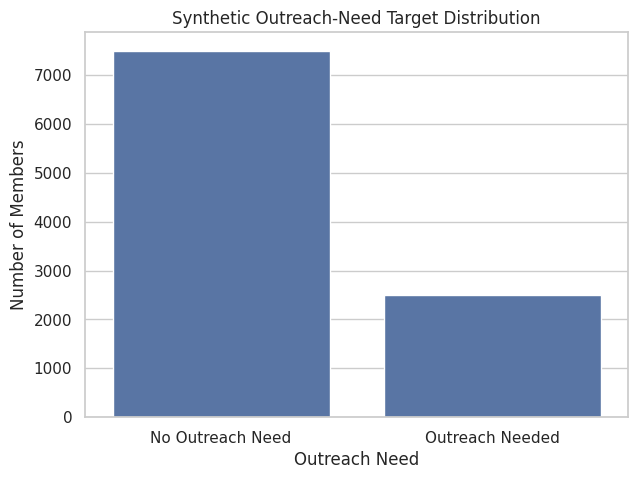

In [ ]:
# ============================================================
# STEP 68: VISUALIZE THE OUTREACH-NEED TARGET
# ============================================================

# I am visualizing the target distribution to make sure
# both classes are represented clearly before model training.

plt.figure(figsize=(7, 5))

sns.countplot(
    data=model_df,
    x="outreach_need"
)

plt.title("Synthetic Outreach-Need Target Distribution")
plt.xlabel("Outreach Need")
plt.ylabel("Number of Members")

plt.xticks(
    [0, 1],
    ["No Outreach Need", "Outreach Needed"]
)

plt.show()

In [ ]:
# ============================================================
# STEP 69: VALIDATE THE TARGET AGAINST KEY HEALTHCARE SIGNALS
# ============================================================

# I am comparing the average values of important healthcare
# features between the two target groups.
#
# This helps me verify that the synthetic target is behaving
# consistently with the project logic.

target_comparison = model_df.groupby(
    "outreach_need"
)[
    [
        "condition_count",
        "acute_utilization_30d",
        "care_gap_count",
        "social_risk_count",
        "recent_discharge_30d",
        "post_discharge_24h"
    ]
].mean()

target_comparison

,condition_count,acute_utilization_30d,care_gap_count,social_risk_count,recent_discharge_30d,post_discharge_24h
outreach_need,,,,,,
0,0.298667,0.2084,0.265467,0.314133,0.007333,0.000267
1,0.915200,0.6048,0.801200,0.561600,0.105600,0.012000


In [ ]:
# ============================================================
# STEP 70: CHECK FOR TARGET LEAKAGE
# ============================================================

# I am making sure that the target column is not accidentally
# included in the model feature list.

if "outreach_need" in model_features:
    print("WARNING: Target leakage detected.")
else:
    print("No direct target leakage detected.")

No direct target leakage detected.


In [ ]:
# ============================================================
# STEP 71: SEPARATE FEATURES AND TARGET
# ============================================================

# X contains the healthcare features that the models will use.
# y contains the synthetic outreach-need outcome the models
# are expected to predict.

X = model_df[model_features].copy()

y = model_df["outreach_need"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (10000, 22)
Target shape: (10000,)


In [ ]:
# ============================================================
# STEP 72: REVIEW THE FINAL MODEL INPUTS
# ============================================================

# I am reviewing the final feature list before splitting
# the data into training and testing sets.

print("Model features:")

for number, feature in enumerate(
    X.columns,
    start=1
):
    print(number, feature)

Model features:
1 age
2 condition_count
3 diabetes
4 hypertension
5 heart_disease
6 er_visits_30d
7 hospitalizations_30d
8 outpatient_visits_30d
9 total_utilization_30d
10 acute_utilization_30d
11 recent_discharge_30d
12 days_since_discharge
13 post_discharge_24h
14 care_gap_count
15 overdue_screening
16 overdue_lab
17 medication_gap
18 transportation_barrier
19 food_insecurity
20 housing_instability
21 financial_barrier
22 social_risk_count


In [ ]:
# ============================================================
# STEP 72: REVIEW THE FINAL MODEL INPUTS
# ============================================================

# I am reviewing the final feature list before splitting
# the data into training and testing sets.

print("Model features:")

for number, feature in enumerate(
    X.columns,
    start=1
):
    print(number, feature)

Model features:
1 age
2 condition_count
3 diabetes
4 hypertension
5 heart_disease
6 er_visits_30d
7 hospitalizations_30d
8 outpatient_visits_30d
9 total_utilization_30d
10 acute_utilization_30d
11 recent_discharge_30d
12 days_since_discharge
13 post_discharge_24h
14 care_gap_count
15 overdue_screening
16 overdue_lab
17 medication_gap
18 transportation_barrier
19 food_insecurity
20 housing_instability
21 financial_barrier
22 social_risk_count


In [ ]:
# ============================================================
# STEP 74: HANDLE DISCHARGE RECENCY FOR MODELING
# ============================================================

# A missing days_since_discharge value means that the member
# did not have a recent discharge.
#
# I am using -1 to distinguish this situation from:
#
# 0  -> discharge occurred on day 0
# 1  -> discharge occurred 1 day ago
# ...
# 30 -> discharge occurred 30 days ago
#
# This transformation is used only for model training.

X["days_since_discharge"] = (
    X["days_since_discharge"]
    .fillna(-1)
)

print(
    "Remaining missing values:",
    X.isnull().sum().sum()
)

Remaining missing values: 0


In [ ]:
# ============================================================
# STEP 75: FINAL MODEL DATA VALIDATION
# ============================================================

# Before training the models, I am performing one final
# validation of the feature matrix and target.

print("Number of rows:", len(X))
print("Number of features:", X.shape[1])
print("Missing values:", X.isnull().sum().sum())
print("Target values:", y.unique())
print("Target counts:")
print(y.value_counts())

Number of rows: 10000
Number of features: 22
Missing values: 0
Target values: [0 1]
Target counts:
outreach_need
0    7500
1    2500
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 76: SPLIT THE DATA INTO TRAINING AND TESTING SETS
# ============================================================

# I am keeping 80% of the data for model training
# and 20% for evaluating how well the models perform
# on unseen members.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 8000
Testing records: 2000


In [ ]:
# ============================================================
# STEP 77: VERIFY TARGET DISTRIBUTION AFTER THE SPLIT
# ============================================================

# I am checking the class distribution in both training
# and testing sets to make sure stratification worked correctly.

print("Training target distribution:")
print(
    y_train.value_counts(normalize=True)
    .round(3)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True)
    .round(3)
)

Training target distribution:
outreach_need
0    0.75
1    0.25
Name: proportion, dtype: float64

Testing target distribution:
outreach_need
0    0.75
1    0.25
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# STEP 78: TRAIN THE LOGISTIC REGRESSION BASELINE
# ============================================================

# I am starting with Logistic Regression as a simple baseline.
# This gives us a reference point that we can compare against
# the more advanced tree-based models.

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
# ============================================================
# STEP 79: GENERATE LOGISTIC REGRESSION PREDICTIONS
# ============================================================

# I am generating both class predictions and probabilities
# so that we can later calculate classification metrics
# and compare this model with Random Forest and CatBoost.

logistic_pred = logistic_model.predict(X_test)

logistic_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated.")
print("First 10 predicted classes:")
print(logistic_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(logistic_prob[:10])

Predictions generated.
First 10 predicted classes:
[0 1 0 0 0 1 0 0 0 0]

First 10 predicted probabilities:
[0.07295662 0.96930288 0.12913949 0.06681155 0.37221154 0.59004313
 0.06876388 0.03733066 0.37153726 0.07342864]


In [ ]:
# ============================================================
# STEP 80: EVALUATE LOGISTIC REGRESSION
# ============================================================

# I am evaluating the baseline model using multiple metrics.
# Accuracy alone is not enough for our outreach-prioritization
# problem, so I am also checking precision, recall, F1,
# PR-AUC, and ROC-AUC.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred
)

logistic_recall = recall_score(
    y_test,
    logistic_pred
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred
)

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_prob
)

logistic_pr_auc = average_precision_score(
    y_test,
    logistic_prob
)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")
print(f"PR-AUC   : {logistic_pr_auc:.4f}")




#

Logistic Regression Performance
--------------------------------
Accuracy : 0.8480
Precision: 0.7737
Recall   : 0.5540
F1 Score : 0.6457
ROC-AUC  : 0.8674
PR-AUC   : 0.7531


In [ ]:
# ============================================================
# STEP 81: CHECK THE LOGISTIC REGRESSION CONFUSION MATRIX
# ============================================================

# I am checking the confusion matrix to understand
# how many outreach-needed members were correctly and
# incorrectly identified.

logistic_cm = confusion_matrix(
    y_test,
    logistic_pred
)

print("Confusion Matrix:")
print(logistic_cm)




Confusion Matrix:
[[1419   81]
 [ 223  277]]


In [ ]:
# STEP 82: VIEW THE CLASSIFICATION REPORT
# ============================================================

# I am checking the detailed precision, recall, and F1
# values for both target classes.

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=[
            "No Outreach Need",
            "Outreach Needed"
        ]
    )
)

                  precision    recall  f1-score   support

No Outreach Need       0.86      0.95      0.90      1500
 Outreach Needed       0.77      0.55      0.65       500

        accuracy                           0.85      2000
       macro avg       0.82      0.75      0.77      2000
    weighted avg       0.84      0.85      0.84      2000



In [ ]:
# ============================================================
# STEP 83: TRAIN THE RANDOM FOREST MODEL
# ============================================================

# I am now training Random Forest as the second candidate model.
# This gives us a nonlinear tree-based model to compare against
# the Logistic Regression baseline.

from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
# ============================================================
# STEP 84: GENERATE RANDOM FOREST PREDICTIONS
# ============================================================

# I am generating both class predictions and probabilities
# so that the Random Forest can be evaluated using the same
# metrics as Logistic Regression.

rf_pred = random_forest_model.predict(
    X_test
)

rf_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]

print("Random Forest predictions generated.")

print("\nFirst 10 predicted classes:")
print(rf_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(rf_prob[:10])

Random Forest predictions generated.

First 10 predicted classes:
[0 1 0 0 0 1 0 0 0 0]

First 10 predicted probabilities:
[0.25333333 0.62666667 0.21880952 0.01333333 0.17359524 0.56285714
 0.37002353 0.26818389 0.2        0.01069048]


In [ ]:
# ============================================================
# STEP 85: EVALUATE RANDOM FOREST
# ============================================================

# I am evaluating Random Forest using the same metrics used
# for Logistic Regression so that the comparison is fair.

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_prob
)

rf_pr_auc = average_precision_score(
    y_test,
    rf_prob
)

print("Random Forest Performance")
print("--------------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

Random Forest Performance
--------------------------------
Accuracy : 0.7945
Precision: 0.5941
Recall   : 0.5620
F1 Score : 0.5776
ROC-AUC  : 0.8134
PR-AUC   : 0.6146


In [ ]:
# ============================================================
# STEP 86: CHECK THE RANDOM FOREST CONFUSION MATRIX
# ============================================================

# I am checking how many outreach-needed members were
# correctly identified and how many were missed.

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[1308  192]
 [ 219  281]]


In [ ]:
# ============================================================
# STEP 87: VIEW THE RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

# I am reviewing precision, recall, and F1-score for
# both target classes.

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "No Outreach Need",
            "Outreach Needed"
        ]
    )
)

                  precision    recall  f1-score   support

No Outreach Need       0.86      0.87      0.86      1500
 Outreach Needed       0.59      0.56      0.58       500

        accuracy                           0.79      2000
       macro avg       0.73      0.72      0.72      2000
    weighted avg       0.79      0.79      0.79      2000



In [ ]:
# ============================================================
# STEP 88: INSTALL CATBOOST
# ============================================================

# CatBoost is the third candidate model in our comparison.
# I am installing it so that it can be evaluated against
# Logistic Regression and Random Forest.

!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
# ============================================================
# STEP 89: TRAIN THE CATBOOST MODEL
# ============================================================

# I am now training CatBoost as the third candidate model.
# CatBoost is well suited to structured tabular data and
# will later allow us to generate SHAP explanations.

from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train,
    y_train
)

print("CatBoost training completed.")

CatBoost training completed.


In [ ]:
# ============================================================
# STEP 90: GENERATE CATBOOST PREDICTIONS
# ============================================================

# I am generating both class predictions and probabilities
# so that CatBoost can be evaluated using exactly the same
# metrics as the other two models.

catboost_pred = catboost_model.predict(
    X_test
).astype(int).ravel()

catboost_prob = catboost_model.predict_proba(
    X_test
)[:, 1]

print("CatBoost predictions generated.")

print("\nFirst 10 predicted classes:")
print(catboost_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(catboost_prob[:10])

CatBoost predictions generated.

First 10 predicted classes:
[0 1 0 0 0 1 0 0 0 0]

First 10 predicted probabilities:
[0.09447556 0.98198251 0.12218204 0.09391192 0.39365108 0.66602401
 0.05126603 0.03450784 0.230976   0.08910152]


In [ ]:
# ============================================================
# STEP 91: EVALUATE CATBOOST
# ============================================================

# I am evaluating CatBoost using exactly the same metrics
# used for Logistic Regression and Random Forest.
#
# This allows a fair comparison across all three models.

catboost_accuracy = accuracy_score(
    y_test,
    catboost_pred
)

catboost_precision = precision_score(
    y_test,
    catboost_pred
)

catboost_recall = recall_score(
    y_test,
    catboost_pred
)

catboost_f1 = f1_score(
    y_test,
    catboost_pred
)

catboost_roc_auc = roc_auc_score(
    y_test,
    catboost_prob
)

catboost_pr_auc = average_precision_score(
    y_test,
    catboost_prob
)

print("CatBoost Performance")
print("--------------------------------")
print(f"Accuracy : {catboost_accuracy:.4f}")
print(f"Precision: {catboost_precision:.4f}")
print(f"Recall   : {catboost_recall:.4f}")
print(f"F1 Score : {catboost_f1:.4f}")
print(f"ROC-AUC  : {catboost_roc_auc:.4f}")
print(f"PR-AUC   : {catboost_pr_auc:.4f}")

CatBoost Performance
--------------------------------
Accuracy : 0.8395
Precision: 0.7493
Recall   : 0.5380
F1 Score : 0.6263
ROC-AUC  : 0.8604
PR-AUC   : 0.7360


In [ ]:
# ============================================================
# STEP 92: CHECK THE CATBOOST CONFUSION MATRIX
# ============================================================

# I am checking how many outreach-needed members were
# correctly identified and how many were missed.

catboost_cm = confusion_matrix(
    y_test,
    catboost_pred
)

print("CatBoost Confusion Matrix:")
print(catboost_cm)

CatBoost Confusion Matrix:
[[1410   90]
 [ 231  269]]


In [ ]:
# ============================================================
# STEP 93: VIEW THE CATBOOST CLASSIFICATION REPORT
# ============================================================

# I am reviewing the detailed performance for both
# outreach classes.

print(
    classification_report(
        y_test,
        catboost_pred,
        target_names=[
            "No Outreach Need",
            "Outreach Needed"
        ]
    )
)

                  precision    recall  f1-score   support

No Outreach Need       0.86      0.94      0.90      1500
 Outreach Needed       0.75      0.54      0.63       500

        accuracy                           0.84      2000
       macro avg       0.80      0.74      0.76      2000
    weighted avg       0.83      0.84      0.83      2000



In [ ]:
# ============================================================
# STEP 94: INSTALL XGBOOST
# ============================================================

# XGBoost is the fourth candidate model in our comparison.
# I am installing it so that we can evaluate another
# gradient-boosting approach on the same healthcare features.

!pip install xgboost -q

In [ ]:
# ============================================================
# STEP 95: TRAIN THE XGBOOST MODEL
# ============================================================

# I am training XGBoost as the fourth candidate model.
# It is another tree-based boosting algorithm that can
# capture nonlinear relationships in structured data.

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
# ============================================================
# STEP 96: GENERATE XGBOOST PREDICTIONS
# ============================================================

# I am generating class predictions and probabilities so that
# XGBoost can be evaluated using exactly the same metrics as
# the other candidate models.

xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

print("XGBoost predictions generated.")

print("\nFirst 10 predicted classes:")
print(xgb_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(xgb_prob[:10])

XGBoost predictions generated.

First 10 predicted classes:
[0 1 0 0 0 1 0 0 0 0]

First 10 predicted probabilities:
[0.07762112 0.95160574 0.13249992 0.09124392 0.40196157 0.69729656
 0.07713474 0.03340956 0.22925481 0.08690994]


In [ ]:
# ============================================================
# STEP 97: EVALUATE XGBOOST
# ============================================================

# I am evaluating XGBoost using the same metrics used for
# all previous models so that the comparison remains fair.

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_prob
)

xgb_pr_auc = average_precision_score(
    y_test,
    xgb_prob
)

print("XGBoost Performance")
print("--------------------------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

XGBoost Performance
--------------------------------
Accuracy : 0.8385
Precision: 0.7335
Recall   : 0.5560
F1 Score : 0.6325
ROC-AUC  : 0.8603
PR-AUC   : 0.7375


In [ ]:
# ============================================================
# STEP 98: CHECK THE XGBOOST CONFUSION MATRIX
# ============================================================

# I am checking how many outreach-needed members were
# correctly identified and how many were missed.

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

print("XGBoost Confusion Matrix:")
print(xgb_cm)

XGBoost Confusion Matrix:
[[1399  101]
 [ 222  278]]


In [ ]:
# ============================================================
# STEP 99: VIEW THE XGBOOST CLASSIFICATION REPORT
# ============================================================

# I am reviewing the detailed performance for both
# outreach classes.

print(
    classification_report(
        y_test,
        xgb_pred,
        target_names=[
            "No Outreach Need",
            "Outreach Needed"
        ]
    )
)

                  precision    recall  f1-score   support

No Outreach Need       0.86      0.93      0.90      1500
 Outreach Needed       0.73      0.56      0.63       500

        accuracy                           0.84      2000
       macro avg       0.80      0.74      0.76      2000
    weighted avg       0.83      0.84      0.83      2000



In [ ]:
# ============================================================
# STEP 100: PREPARE THE SVM MODEL
# ============================================================

# I am using Support Vector Machine as the fifth
# classification model for our comparison.
#
# SVM can work well with structured data when the features
# are properly scaled, so I am using StandardScaler before
# the classifier.

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        )
    )
])

print("SVM model prepared.")

SVM model prepared.


In [ ]:
# ============================================================
# STEP 101: TRAIN THE SVM MODEL
# ============================================================

# I am training SVM using the same training data used
# for all the other candidate models.

svm_model.fit(
    X_train,
    y_train
)

print("SVM training completed.")

SVM training completed.


In [ ]:
# ============================================================
# STEP 102: GENERATE SVM PREDICTIONS
# ============================================================

# I am generating both class predictions and probabilities
# so that SVM can be evaluated using the same metrics as
# the other classification models.

svm_pred = svm_model.predict(
    X_test
)

svm_prob = svm_model.predict_proba(
    X_test
)[:, 1]

print("SVM predictions generated.")

print("\nFirst 10 predicted classes:")
print(svm_pred[:10])

print("\nFirst 10 predicted probabilities:")
print(svm_prob[:10])

SVM predictions generated.

First 10 predicted classes:
[0 1 0 0 0 0 0 0 0 0]

First 10 predicted probabilities:
[0.12810117 0.84131566 0.1315484  0.09680238 0.35520666 0.4509148
 0.13098851 0.1308765  0.18623169 0.12502288]


In [ ]:
# ============================================================
# STEP 103: EVALUATE SVM
# ============================================================

# I am evaluating SVM using the same metrics used for
# Logistic Regression, Random Forest, CatBoost and XGBoost.
#
# This keeps the final model comparison fair.

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_precision = precision_score(
    y_test,
    svm_pred
)

svm_recall = recall_score(
    y_test,
    svm_pred
)

svm_f1 = f1_score(
    y_test,
    svm_pred
)

svm_roc_auc = roc_auc_score(
    y_test,
    svm_prob
)

svm_pr_auc = average_precision_score(
    y_test,
    svm_prob
)

print("SVM Performance")
print("--------------------------------")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")
print(f"ROC-AUC  : {svm_roc_auc:.4f}")
print(f"PR-AUC   : {svm_pr_auc:.4f}")

SVM Performance
--------------------------------
Accuracy : 0.8420
Precision: 0.7857
Recall   : 0.5060
F1 Score : 0.6156
ROC-AUC  : 0.8064
PR-AUC   : 0.7089


In [ ]:
# ============================================================
# STEP 104: CHECK THE SVM CONFUSION MATRIX
# ============================================================

# I am checking how many outreach-needed members were
# correctly identified and how many were missed.

svm_cm = confusion_matrix(
    y_test,
    svm_pred
)

print("SVM Confusion Matrix:")
print(svm_cm)


# ============================================================
# STEP 104B: VIEW THE SVM CLASSIFICATION REPORT
# ============================================================

# I am reviewing precision, recall and F1-score for
# both outreach classes.

print(
    classification_report(
        y_test,
        svm_pred,
        target_names=[
            "No Outreach Need",
            "Outreach Needed"
        ]
    )
)

SVM Confusion Matrix:
[[1431   69]
 [ 247  253]]
                  precision    recall  f1-score   support

No Outreach Need       0.85      0.95      0.90      1500
 Outreach Needed       0.79      0.51      0.62       500

        accuracy                           0.84      2000
       macro avg       0.82      0.73      0.76      2000
    weighted avg       0.84      0.84      0.83      2000



In [ ]:
# ============================================================
# STEP 105: FINAL MODEL COMPARISON
# ============================================================

# I am bringing the results from all five classification
# models into one table so that they can be compared fairly.

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost",
        "XGBoost",
        "SVM"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        catboost_accuracy,
        xgb_accuracy,
        svm_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision,
        catboost_precision,
        xgb_precision,
        svm_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall,
        catboost_recall,
        xgb_recall,
        svm_recall
    ],

    "F1 Score": [
        logistic_f1,
        rf_f1,
        catboost_f1,
        xgb_f1,
        svm_f1
    ],

    "PR-AUC": [
        logistic_pr_auc,
        rf_pr_auc,
        catboost_pr_auc,
        xgb_pr_auc,
        svm_pr_auc
    ],

    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc,
        catboost_roc_auc,
        xgb_roc_auc,
        svm_roc_auc
    ]
})

# I am rounding the values so the comparison is easier
# to read.

model_comparison = model_comparison.round(4)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,PR-AUC,ROC-AUC
0,Logistic Regression,0.8480,0.7737,0.554,0.6457,0.7531,0.8674
1,Random Forest,0.7945,0.5941,0.562,0.5776,0.6146,0.8134
2,CatBoost,0.8395,0.7493,0.538,0.6263,0.7360,0.8604
3,XGBoost,0.8385,0.7335,0.556,0.6325,0.7375,0.8603
4,SVM,0.8420,0.7857,0.506,0.6156,0.7089,0.8064


In [ ]:
# ============================================================
# STEP 106: SELECT THE BEST MODEL
# ============================================================

# I am selecting the model with the strongest F1 score.
# PR-AUC, recall, precision and ROC-AUC are used as
# supporting metrics.

best_model_row = model_comparison.loc[
    model_comparison["F1 Score"].idxmax()
]

print("Selected model:")
print(best_model_row)

Selected model:
Model        Logistic Regression
Accuracy                   0.848
Precision                 0.7737
Recall                     0.554
F1 Score                  0.6457
PR-AUC                    0.7531
ROC-AUC                   0.8674
Name: 0, dtype: object


In [ ]:
# ============================================================
# STEP 107: SET THE FINAL MODEL
# ============================================================

# I am assigning the best-performing classification model
# as the final model for the current synthetic prototype.

if best_model_row["Model"] == "Logistic Regression":
    final_model = logistic_model

elif best_model_row["Model"] == "Random Forest":
    final_model = random_forest_model

elif best_model_row["Model"] == "CatBoost":
    final_model = catboost_model

elif best_model_row["Model"] == "XGBoost":
    final_model = xgb_model

elif best_model_row["Model"] == "SVM":
    final_model = svm_model

print(
    "Final model selected:",
    best_model_row["Model"]
)

Final model selected: Logistic Regression


**TRAINING 10K ON LR**

---



---



In [ ]:
# ============================================================
# STEP 107A: RETRAIN FINAL MODEL ON ALL 10,000 MEMBERS
# ============================================================

# The model comparison is already completed.
# Logistic Regression was selected based on the held-out
# 2,000-member test set.

# Now retrain the selected model using the complete
# 10,000-member dataset for final application use.

final_model.fit(X, y)

print("Final Logistic Regression retrained successfully.")
print("Training records used:", len(X))

Final Logistic Regression retrained successfully.
Training records used: 10000


In [ ]:
# ============================================================
# STEP 107B: GENERATE FINAL PREDICTIONS FOR ALL 10,000
# ============================================================

final_pred = final_model.predict(X)

final_prob = final_model.predict_proba(X)[:, 1]

print("Final 10K predictions generated.")

print("\nNumber of predictions:", len(final_pred))

print("\nFirst 10 predictions:")
print(final_pred[:10])

print("\nFirst 10 probabilities:")
print(final_prob[:10])

Final 10K predictions generated.

Number of predictions: 10000

First 10 predictions:
[0 0 1 0 0 0 0 0 0 0]

First 10 probabilities:
[0.01486675 0.30594728 0.96332235 0.02862317 0.04468493 0.35350357
 0.08344725 0.08055113 0.16315583 0.03624948]


In [ ]:
# ============================================================
# STEP 107C: CREATE FINAL 10K PRIORITY OUTPUT
# ============================================================

priority_output_10k = pd.DataFrame({
    "member_id": model_df["member_id"].values,
    "member_name": model_df["member_name"].values,
    "outreach_probability": final_prob
})

# Convert probability to a 0–100 priority score
priority_output_10k["priority_score"] = (
    priority_output_10k["outreach_probability"] * 100
)

# Create priority bands
priority_output_10k["priority_band"] = pd.cut(
    priority_output_10k["priority_score"],
    bins=[-1, 40, 70, 100],
    labels=[
        "Low Priority",
        "Medium Priority",
        "High Priority"
    ]
)

print("Final 10K priority output created.")
print("Number of members:", len(priority_output_10k))

display(
    priority_output_10k.head(10)
)

Final 10K priority output created.
Number of members: 10000


,member_id,member_name,outreach_probability,priority_score,priority_band
0,M00001,Arjun Nair,0.014867,1.486675,Low Priority
1,M00002,Lakshmi Naidu,0.305947,30.594728,Low Priority
2,M00003,Kiran Deshmukh,0.963322,96.332235,High Priority
3,M00004,Arjun Yadav,0.028623,2.862317,Low Priority
4,M00005,Ravi Patel,0.044685,4.468493,Low Priority
5,M00006,Swathi Kapoor,0.353504,35.350357,Low Priority
6,M00007,Rohit Nair,0.083447,8.344725,Low Priority
7,M00008,Asha Nair,0.080551,8.055113,Low Priority
8,M00009,Swathi Reddy,0.163156,16.315583,Low Priority
9,M00010,Varun Iyer,0.036249,3.624948,Low Priority


In [ ]:
# ============================================================
# STEP 107D: VERIFY FINAL 10K PRIORITY OUTPUT
# ============================================================

print("Final 10K priority output verified.")

print("\nNumber of members:")
print(len(priority_output_10k))

print("\nColumns:")
print(priority_output_10k.columns.tolist())

print("\nPriority band distribution:")
print(
    priority_output_10k["priority_band"]
    .value_counts()
)

print("\nPriority score range:")
print(
    "Minimum:",
    priority_output_10k["priority_score"].min()
)

print(
    "Maximum:",
    priority_output_10k["priority_score"].max()
)

print("\nTop 10 prioritized members:")

display(
    priority_output_10k
    .sort_values(
        "priority_score",
        ascending=False
    )
    .head(10)
)

Final 10K priority output verified.

Number of members:
10000

Columns:
['member_id', 'member_name', 'outreach_probability', 'priority_score', 'priority_band']

Priority band distribution:
priority_band
Low Priority       7662
Medium Priority    1249
High Priority      1089
Name: count, dtype: int64

Priority score range:
Minimum: 1.3879699804766448
Maximum: 99.99265288609952

Top 10 prioritized members:


,member_id,member_name,outreach_probability,priority_score,priority_band
8094,M08095,Neha Sharma,0.999927,99.992653,High Priority
1438,M01439,Lakshmi Chowdhury,0.999852,99.985153,High Priority
8552,M08553,Kavya Nair,0.999773,99.977256,High Priority
3754,M03755,Naveen Iyer,0.999742,99.974231,High Priority
8560,M08561,Shreya Rao,0.999730,99.973032,High Priority
3957,M03958,Sneha Chowdhury,0.999689,99.968867,High Priority
4963,M04964,Divya Singh,0.999676,99.967552,High Priority
6487,M06488,Rahul Yadav,0.999653,99.965298,High Priority
9482,M09483,Nikhil Kapoor,0.999642,99.964180,High Priority
4119,M04120,Swathi Iyer,0.999588,99.958823,High Priority


In [ ]:
# ============================================================
# STEP 107E: PREPARE FINAL 10K DATA FOR SHAP
# ============================================================

import shap

# Extract preprocessing/scaling component from final pipeline
scaler = final_model.named_steps["scaler"]

# Extract trained Logistic Regression model
lr_model = final_model.named_steps["model"]

# Transform ALL 10,000 members using the same scaler
X_scaled_10k = scaler.transform(X)

print("Final 10K data prepared for SHAP.")

print("\nMembers:")
print(X_scaled_10k.shape[0])

print("\nFeatures:")
print(X_scaled_10k.shape[1])

Final 10K data prepared for SHAP.

Members:
10000

Features:
22


In [ ]:
# ============================================================
# STEP 107F: CALCULATE SHAP VALUES FOR FINAL 10K
# ============================================================

# Create SHAP LinearExplainer for the final Logistic Regression
explainer_10k = shap.LinearExplainer(
    lr_model,
    X_scaled_10k
)

# Calculate SHAP values for all 10,000 members
shap_values_10k = explainer_10k.shap_values(
    X_scaled_10k
)

print("SHAP values calculated successfully.")

print("\nNumber of members explained:")
print(shap_values_10k.shape[0])

print("\nNumber of features explained:")
print(shap_values_10k.shape[1])

SHAP values calculated successfully.

Number of members explained:
10000

Number of features explained:
22


In [ ]:
# ============================================================
# STEP 107G: CREATE SHAP REASON MAP FOR FINAL 10K
# ============================================================

shap_reason_map_10k = {}

# Use the final 10K SHAP values
# and the original 10K feature matrix X

for position in range(len(X)):

    # Get member ID from the full 10K model dataframe
    member_id = model_df.iloc[position]["member_id"]

    # SHAP values for this member
    member_shap = shap_values_10k[position]

    # Original feature values for this member
    member_values = X.iloc[position]

    # Combine feature names, values and SHAP values
    explanation = pd.DataFrame({
        "Feature": X.columns,
        "Feature Value": member_values.values,
        "SHAP Value": member_shap
    })

    # Keep only factors that increased the model's
    # outreach prediction
    positive_factors = (
        explanation[
            explanation["SHAP Value"] > 0
        ]
        .sort_values(
            "SHAP Value",
            ascending=False
        )
        .head(3)
    )

    reasons = []

    for feature in positive_factors["Feature"]:

        readable_name = (
            feature
            .replace("_", " ")
            .title()
        )

        reasons.append(readable_name)

    shap_reason_map_10k[member_id] = reasons


print("10K SHAP reason map created.")

print(
    "Number of members explained:",
    len(shap_reason_map_10k)
)

10K SHAP reason map created.
Number of members explained: 10000


In [ ]:
# ============================================================
# STEP 107H: CREATE FINAL 10K OUTREACH QUEUE
# ============================================================

final_outreach_queue = priority_output_10k.copy()

print("Final 10K outreach queue created.")
print("Number of members:", len(final_outreach_queue))

display(final_outreach_queue.head(5))

Final 10K outreach queue created.
Number of members: 10000


,member_id,member_name,outreach_probability,priority_score,priority_band
0,M00001,Arjun Nair,0.014867,1.486675,Low Priority
1,M00002,Lakshmi Naidu,0.305947,30.594728,Low Priority
2,M00003,Kiran Deshmukh,0.963322,96.332235,High Priority
3,M00004,Arjun Yadav,0.028623,2.862317,Low Priority
4,M00005,Ravi Patel,0.044685,4.468493,Low Priority


In [ ]:
# ============================================================
# STEP 107I: ADD SHAP REASONS TO FINAL 10K QUEUE
# ============================================================

final_outreach_queue["shap_reasons"] = (
    final_outreach_queue["member_id"].map(
        shap_reason_map_10k
    )
)

print("SHAP reasons added to final 10K queue.")

print(
    "Members with SHAP reasons:",
    final_outreach_queue["shap_reasons"].notna().sum()
)

display(
    final_outreach_queue[
        [
            "member_id",
            "member_name",
            "priority_score",
            "priority_band",
            "shap_reasons"
        ]
    ].head(10)
)

SHAP reasons added to final 10K queue.
Members with SHAP reasons: 10000


,member_id,member_name,priority_score,priority_band,shap_reasons
0,M00001,Arjun Nair,1.486675,Low Priority,[Post Discharge 24H]
1,M00002,Lakshmi Naidu,30.594728,Low Priority,"[Diabetes, Age, Condition Count]"
2,M00003,Kiran Deshmukh,96.332235,High Priority,"[Condition Count, Age, Diabetes]"
3,M00004,Arjun Yadav,2.862317,Low Priority,"[Outpatient Visits 30D, Post Discharge 24H]"
4,M00005,Ravi Patel,4.468493,Low Priority,"[Age, Outpatient Visits 30D, Post Discharge 24H]"
5,M00006,Swathi Kapoor,35.350357,Low Priority,"[Er Visits 30D, Acute Utilization 30D, Hyperte..."
6,M00007,Rohit Nair,8.344725,Low Priority,"[Er Visits 30D, Acute Utilization 30D, Age]"
7,M00008,Asha Nair,8.055113,Low Priority,"[Overdue Screening, Care Gap Count, Outpatient..."
8,M00009,Swathi Reddy,16.315583,Low Priority,"[Social Risk Count, Financial Barrier, Transpo..."
9,M00010,Varun Iyer,3.624948,Low Priority,"[Er Visits 30D, Acute Utilization 30D, Outpati..."


In [ ]:
# ============================================================
# STEP 107J: CREATE HUMAN-READABLE SHAP REASONS
# ============================================================

readable_feature_names = {

    "age":
        "Age contributed to the priority score",

    "condition_count":
        "Multiple chronic conditions contributed to priority",

    "diabetes":
        "Diabetes contributed to the priority score",

    "hypertension":
        "Hypertension contributed to the priority score",

    "heart_disease":
        "Heart disease contributed to the priority score",

    "er_visits_30d":
        "Recent emergency-room visits increased priority",

    "hospitalizations_30d":
        "Recent hospitalization activity increased priority",

    "outpatient_visits_30d":
        "Recent outpatient utilization contributed to priority",

    "recent_discharge_30d":
        "Recent hospital discharge increased priority",

    "days_since_discharge":
        "Recent discharge timing contributed to priority",

    "care_gap_count":
        "Outstanding care gaps increased priority",

    "overdue_screening":
        "Overdue screening increased priority",

    "overdue_lab":
        "Overdue laboratory testing increased priority",

    "medication_gap":
        "Medication gap increased priority",

    "transportation_barrier":
        "Transportation barrier contributed to priority",

    "food_insecurity":
        "Food insecurity contributed to priority",

    "housing_instability":
        "Housing instability contributed to priority",

    "financial_barrier":
        "Financial barrier contributed to priority",

    "post_discharge_24h":
        "Very recent post-discharge status increased priority",

    "social_risk_count":
        "Social-risk factors contributed to priority",

    "acute_utilization_30d":
        "Recent acute-care utilization increased priority",

    "total_utilization_30d":
        "Recent healthcare utilization contributed to priority",

    "clinical_burden":
        "Overall clinical burden contributed to priority",

    "care_gap_burden":
        "Overall care-gap burden contributed to priority",

    "discharge_recency":
        "Discharge recency contributed to priority"
}


def make_readable_reasons_10k(reasons):

    if not isinstance(reasons, list):
        return []

    readable_reasons = []

    for reason in reasons:

        feature_name = (
            str(reason)
            .lower()
            .replace(" ", "_")
        )

        if feature_name in readable_feature_names:

            readable_reasons.append(
                readable_feature_names[feature_name]
            )

        else:

            readable_reasons.append(
                str(reason)
            )

    return readable_reasons


final_outreach_queue["human_readable_reasons"] = (
    final_outreach_queue["shap_reasons"].apply(
        make_readable_reasons_10k
    )
)

print("Human-readable SHAP reasons created.")

display(
    final_outreach_queue[
        [
            "member_id",
            "member_name",
            "shap_reasons",
            "human_readable_reasons"
        ]
    ].head(10)
)

Human-readable SHAP reasons created.


,member_id,member_name,shap_reasons,human_readable_reasons
0,M00001,Arjun Nair,[Post Discharge 24H],[Very recent post-discharge status increased p...
1,M00002,Lakshmi Naidu,"[Diabetes, Age, Condition Count]","[Diabetes contributed to the priority score, A..."
2,M00003,Kiran Deshmukh,"[Condition Count, Age, Diabetes]",[Multiple chronic conditions contributed to pr...
3,M00004,Arjun Yadav,"[Outpatient Visits 30D, Post Discharge 24H]",[Recent outpatient utilization contributed to ...
4,M00005,Ravi Patel,"[Age, Outpatient Visits 30D, Post Discharge 24H]","[Age contributed to the priority score, Recent..."
5,M00006,Swathi Kapoor,"[Er Visits 30D, Acute Utilization 30D, Hyperte...",[Recent emergency-room visits increased priori...
6,M00007,Rohit Nair,"[Er Visits 30D, Acute Utilization 30D, Age]",[Recent emergency-room visits increased priori...
7,M00008,Asha Nair,"[Overdue Screening, Care Gap Count, Outpatient...","[Overdue screening increased priority, Outstan..."
8,M00009,Swathi Reddy,"[Social Risk Count, Financial Barrier, Transpo...","[Social-risk factors contributed to priority, ..."
9,M00010,Varun Iyer,"[Er Visits 30D, Acute Utilization 30D, Outpati...",[Recent emergency-room visits increased priori...


In [ ]:
# ============================================================
# STEP 107K: ADD CARE-MANAGEMENT FEATURES
# ============================================================

care_features = [
    "post_discharge_24h",
    "recent_discharge_30d",
    "medication_gap",
    "overdue_screening",
    "overdue_lab",
    "transportation_barrier",
    "food_insecurity",
    "housing_instability",
    "financial_barrier",
    "care_gap_count"
]

missing_features = [
    col
    for col in care_features
    if col not in model_df.columns
]

if missing_features:

    print("ERROR: Missing care-management columns:")
    print(missing_features)

else:

    care_feature_data = model_df[
        ["member_id"] + care_features
    ].copy()

    final_outreach_queue = final_outreach_queue.merge(
        care_feature_data,
        on="member_id",
        how="left"
    )

    print("Care-management features added successfully.")

    print(
        "Final queue shape:",
        final_outreach_queue.shape
    )

Care-management features added successfully.
Final queue shape: (10000, 17)


In [ ]:
# ============================================================
# STEP 107L: GENERATE NEXT-BEST ACTION
# ============================================================

final_outreach_queue["next_best_action"] = (
    final_outreach_queue.apply(
        get_next_best_action,
        axis=1
    )
)

print("Next-best actions generated successfully.")

print(
    "Members with actions:",
    final_outreach_queue["next_best_action"].notna().sum()
)

display(
    final_outreach_queue[
        [
            "member_id",
            "member_name",
            "priority_band",
            "next_best_action"
        ]
    ].head(10)
)

Next-best actions generated successfully.
Members with actions: 10000


,member_id,member_name,priority_band,next_best_action
0,M00001,Arjun Nair,Low Priority,Routine care-management follow-up
1,M00002,Lakshmi Naidu,Low Priority,Address transportation barrier
2,M00003,Kiran Deshmukh,High Priority,Arrange overdue laboratory test
3,M00004,Arjun Yadav,Low Priority,Routine care-management follow-up
4,M00005,Ravi Patel,Low Priority,Routine care-management follow-up
5,M00006,Swathi Kapoor,Low Priority,Routine care-management follow-up
6,M00007,Rohit Nair,Low Priority,Routine care-management follow-up
7,M00008,Asha Nair,Low Priority,Schedule overdue screening
8,M00009,Swathi Reddy,Low Priority,Address transportation barrier
9,M00010,Varun Iyer,Low Priority,Routine care-management follow-up


In [ ]:
# ============================================================
# STEP 107M: CREATE WHY-PRIORITIZED EXPLANATION
# ============================================================

def create_explanation_10k(reasons):

    if not isinstance(reasons, list) or len(reasons) == 0:

        return (
            "Priority was influenced by available "
            "member-level factors."
        )

    return (
        "Priority influenced by: "
        + ", ".join(reasons)
        + "."
    )


final_outreach_queue["why_prioritized"] = (
    final_outreach_queue[
        "human_readable_reasons"
    ].apply(
        create_explanation_10k
    )
)

print("Priority explanations created.")

display(
    final_outreach_queue[
        [
            "member_id",
            "member_name",
            "priority_score",
            "priority_band",
            "why_prioritized",
            "next_best_action"
        ]
    ].head(10)
)

Priority explanations created.


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action
0,M00001,Arjun Nair,1.486675,Low Priority,Priority influenced by: Very recent post-disch...,Routine care-management follow-up
1,M00002,Lakshmi Naidu,30.594728,Low Priority,Priority influenced by: Diabetes contributed t...,Address transportation barrier
2,M00003,Kiran Deshmukh,96.332235,High Priority,Priority influenced by: Multiple chronic condi...,Arrange overdue laboratory test
3,M00004,Arjun Yadav,2.862317,Low Priority,Priority influenced by: Recent outpatient util...,Routine care-management follow-up
4,M00005,Ravi Patel,4.468493,Low Priority,Priority influenced by: Age contributed to the...,Routine care-management follow-up
5,M00006,Swathi Kapoor,35.350357,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up
6,M00007,Rohit Nair,8.344725,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up
7,M00008,Asha Nair,8.055113,Low Priority,Priority influenced by: Overdue screening incr...,Schedule overdue screening
8,M00009,Swathi Reddy,16.315583,Low Priority,Priority influenced by: Social-risk factors co...,Address transportation barrier
9,M00010,Varun Iyer,3.624948,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up


In [ ]:
# ============================================================
# STEP 107N: CREATE FINAL 10K CARE MANAGER VIEW
# ============================================================

care_manager_view_10k = final_outreach_queue[
    [
        "member_id",
        "member_name",
        "priority_score",
        "priority_band",
        "why_prioritized",
        "next_best_action"
    ]
].copy()

print("Final 10K Care Manager View created.")

print(
    "Number of members:",
    len(care_manager_view_10k)
)

print("\nColumns:")
print(
    care_manager_view_10k.columns.tolist()
)

display(
    care_manager_view_10k.head(10)
)

Final 10K Care Manager View created.
Number of members: 10000

Columns:
['member_id', 'member_name', 'priority_score', 'priority_band', 'why_prioritized', 'next_best_action']


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action
0,M00001,Arjun Nair,1.486675,Low Priority,Priority influenced by: Very recent post-disch...,Routine care-management follow-up
1,M00002,Lakshmi Naidu,30.594728,Low Priority,Priority influenced by: Diabetes contributed t...,Address transportation barrier
2,M00003,Kiran Deshmukh,96.332235,High Priority,Priority influenced by: Multiple chronic condi...,Arrange overdue laboratory test
3,M00004,Arjun Yadav,2.862317,Low Priority,Priority influenced by: Recent outpatient util...,Routine care-management follow-up
4,M00005,Ravi Patel,4.468493,Low Priority,Priority influenced by: Age contributed to the...,Routine care-management follow-up
5,M00006,Swathi Kapoor,35.350357,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up
6,M00007,Rohit Nair,8.344725,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up
7,M00008,Asha Nair,8.055113,Low Priority,Priority influenced by: Overdue screening incr...,Schedule overdue screening
8,M00009,Swathi Reddy,16.315583,Low Priority,Priority influenced by: Social-risk factors co...,Address transportation barrier
9,M00010,Varun Iyer,3.624948,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up


In [ ]:
# ============================================================
# STEP 107O: SORT FINAL OUTREACH QUEUE
# ============================================================

care_manager_view_10k = (
    care_manager_view_10k
    .sort_values(
        "priority_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Final outreach queue sorted by priority.")

display(
    care_manager_view_10k.head(10)
)

Final outreach queue sorted by priority.


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action
0,M08095,Neha Sharma,99.992653,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
1,M01439,Lakshmi Chowdhury,99.985153,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
2,M08553,Kavya Nair,99.977256,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
3,M03755,Naveen Iyer,99.974231,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
4,M08561,Shreya Rao,99.973032,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
5,M03958,Sneha Chowdhury,99.968867,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
6,M04964,Divya Singh,99.967552,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
7,M06488,Rahul Yadav,99.965298,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
8,M09483,Nikhil Kapoor,99.964180,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
9,M04120,Swathi Iyer,99.958823,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up


In [ ]:
# ============================================================
# STEP 107P: FINAL 10K VALIDATION
# ============================================================

print("=" * 60)
print("FINAL 10K OUTREACH PIPELINE VALIDATION")
print("=" * 60)

print("\nTotal members:")
print(len(care_manager_view_10k))

print("\nMissing values:")
print(
    care_manager_view_10k.isna().sum()
)

print("\nPriority distribution:")
print(
    care_manager_view_10k[
        "priority_band"
    ].value_counts()
)

print("\nPriority score range:")

print(
    "Minimum:",
    care_manager_view_10k["priority_score"].min()
)

print(
    "Maximum:",
    care_manager_view_10k["priority_score"].max()
)

print("\nRequired columns:")
print(
    care_manager_view_10k.columns.tolist()
)

print("\nTop 10 members:")

display(
    care_manager_view_10k.head(10)
)

FINAL 10K OUTREACH PIPELINE VALIDATION

Total members:
10000

Missing values:
member_id           0
member_name         0
priority_score      0
priority_band       0
why_prioritized     0
next_best_action    0
dtype: int64

Priority distribution:
priority_band
Low Priority       7662
Medium Priority    1249
High Priority      1089
Name: count, dtype: int64

Priority score range:
Minimum: 1.3879699804766448
Maximum: 99.99265288609952

Required columns:
['member_id', 'member_name', 'priority_score', 'priority_band', 'why_prioritized', 'next_best_action']

Top 10 members:


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action
0,M08095,Neha Sharma,99.992653,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
1,M01439,Lakshmi Chowdhury,99.985153,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
2,M08553,Kavya Nair,99.977256,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
3,M03755,Naveen Iyer,99.974231,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
4,M08561,Shreya Rao,99.973032,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
5,M03958,Sneha Chowdhury,99.968867,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
6,M04964,Divya Singh,99.967552,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
7,M06488,Rahul Yadav,99.965298,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
8,M09483,Nikhil Kapoor,99.964180,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
9,M04120,Swathi Iyer,99.958823,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up


In [ ]:
# ============================================================
# STEP 135: PREPARE GENAI INPUT
# ============================================================

# I am preparing the structured information that will be
# provided to the GenAI call-script component.
#
# The ML model and rule engine have already made the
# prioritization decision.
#
# GenAI will only help convert that information into a
# natural communication guide.
genai_input = care_manager_view_10k[
    [
        "member_id",
        "member_name",
        "priority_score",
        "priority_band",
        "why_prioritized",
        "next_best_action"
    ]
].copy()

print("GenAI input prepared.")
print("Number of members:", len(genai_input))

genai_input.head(10)

GenAI input prepared.
Number of members: 10000


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action
0,M08095,Neha Sharma,99.992653,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
1,M01439,Lakshmi Chowdhury,99.985153,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
2,M08553,Kavya Nair,99.977256,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
3,M03755,Naveen Iyer,99.974231,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
4,M08561,Shreya Rao,99.973032,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
5,M03958,Sneha Chowdhury,99.968867,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
6,M04964,Divya Singh,99.967552,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
7,M06488,Rahul Yadav,99.965298,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
8,M09483,Nikhil Kapoor,99.964180,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up
9,M04120,Swathi Iyer,99.958823,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up


In [ ]:
# ============================================================
# STEP 136: CREATE THE GENAI CALL-SCRIPT PROMPT
# ============================================================

# I am creating a structured prompt for the GenAI component.
#
# The ML model has already determined the priority.
# SHAP has already explained the important factors.
# The rule engine has already selected the next-best action.
#
# GenAI will only turn this information into a natural,
# respectful call guide for the care manager.

def create_call_script_prompt(row):

    prompt = f"""
You are a care-management outreach assistant.

Create a short, natural call guide for a care manager.

Member name: {row["member_name"]}

Priority level: {row["priority_band"]}

Priority score: {row["priority_score"]:.2f}

Why the member was prioritized:
{row["why_prioritized"]}

Recommended next-best action:
{row["next_best_action"]}

Instructions:
- Use a warm and respectful tone.
- Do not make a diagnosis.
- Do not invent medical information.
- Do not claim that the member has a condition unless it
  is explicitly provided in the input.
- Do not provide treatment instructions.
- Keep the conversation concise.
- The care manager should verify information with the member.
- Focus on the recommended care-management action.
- Do not mention SHAP, machine learning, probability, or
  priority scores to the member.
- Include a brief opening, reason for the call, and next step.
"""

    return prompt.strip()


# I am generating a prompt for every prioritized member.

genai_input["call_script_prompt"] = (
    genai_input.apply(
        create_call_script_prompt,
        axis=1
    )
)

print("Call-script prompts created.")

Call-script prompts created.


In [ ]:
# ============================================================
# STEP 137: REVIEW A SAMPLE CALL-SCRIPT PROMPT
# ============================================================

# I am reviewing one generated prompt before connecting
# it to an actual GenAI service.

print(
    genai_input.iloc[0]["call_script_prompt"]
)

You are a care-management outreach assistant.

Create a short, natural call guide for a care manager.

Member name: Neha Sharma

Priority level: High Priority

Priority score: 99.99

Why the member was prioritized:
Priority influenced by: Recent hospital discharge increased priority, Outstanding care gaps increased priority, Multiple chronic conditions contributed to priority.

Recommended next-best action:
Review recent discharge and arrange follow-up

Instructions:
- Use a warm and respectful tone.
- Do not make a diagnosis.
- Do not invent medical information.
- Do not claim that the member has a condition unless it
  is explicitly provided in the input.
- Do not provide treatment instructions.
- Keep the conversation concise.
- The care manager should verify information with the member.
- Focus on the recommended care-management action.
- Do not mention SHAP, machine learning, probability, or
  priority scores to the member.
- Include a brief opening, reason for the call, and next 

In [ ]:
# ============================================================
# STEP 138: CREATE A FALLBACK CALL SCRIPT
# ============================================================

# I am creating a simple rule-based fallback script.
#
# This ensures the application can still provide a useful
# outreach guide even when an LLM is unavailable.

def create_fallback_script(row):

    name = row["member_name"]
    action = row["next_best_action"]

    script = (
        f"Hello {name}, this is a care-management call. "
        f"I'm reaching out to follow up regarding your care. "
        f"We would like to help with the following: {action}. "
        f"I'd like to check how things are going and see "
        f"whether you need any support with this next step."
    )

    return script


genai_input["fallback_call_script"] = (
    genai_input.apply(
        create_fallback_script,
        axis=1
    )
)

print("Fallback call scripts created.")

Fallback call scripts created.


In [ ]:
# ============================================================
# STEP 139: REVIEW THE GENAI CALL-SCRIPT DATA
# ============================================================

# I am reviewing the information that will be available
# to the Call Script Copilot.

genai_input[
    [
        "member_id",
        "member_name",
        "priority_score",
        "priority_band",
        "next_best_action",
        "fallback_call_script"
    ]
].head(10)

,member_id,member_name,priority_score,priority_band,next_best_action,fallback_call_script
0,M08095,Neha Sharma,99.992653,High Priority,Review recent discharge and arrange follow-up,"Hello Neha Sharma, this is a care-management c..."
1,M01439,Lakshmi Chowdhury,99.985153,High Priority,Review recent discharge and arrange follow-up,"Hello Lakshmi Chowdhury, this is a care-manage..."
2,M08553,Kavya Nair,99.977256,High Priority,Review recent discharge and arrange follow-up,"Hello Kavya Nair, this is a care-management ca..."
3,M03755,Naveen Iyer,99.974231,High Priority,Review recent discharge and arrange follow-up,"Hello Naveen Iyer, this is a care-management c..."
4,M08561,Shreya Rao,99.973032,High Priority,Review recent discharge and arrange follow-up,"Hello Shreya Rao, this is a care-management ca..."
5,M03958,Sneha Chowdhury,99.968867,High Priority,Review recent discharge and arrange follow-up,"Hello Sneha Chowdhury, this is a care-manageme..."
6,M04964,Divya Singh,99.967552,High Priority,Review recent discharge and arrange follow-up,"Hello Divya Singh, this is a care-management c..."
7,M06488,Rahul Yadav,99.965298,High Priority,Review recent discharge and arrange follow-up,"Hello Rahul Yadav, this is a care-management c..."
8,M09483,Nikhil Kapoor,99.964180,High Priority,Review recent discharge and arrange follow-up,"Hello Nikhil Kapoor, this is a care-management..."
9,M04120,Swathi Iyer,99.958823,High Priority,Review recent discharge and arrange follow-up,"Hello Swathi Iyer, this is a care-management c..."


In [ ]:
# ============================================================
# STEP 140: ADD MEMBER FEATURES TO GENAI INPUT
# ============================================================

# I am bringing the original member-level care-management
# features into the GenAI input.
#
# The GenAI layer needs these features only to create a
# context-aware communication script.
#
# The ML model and priority score have already been finalized.

genai_features = [
    "post_discharge_24h",
    "recent_discharge_30d"
]


# I am selecting the member ID and the features needed
# for the member-facing call script.

member_script_data = model_df[
    ["member_id"] + genai_features
].copy()


# I am attaching the features to the existing GenAI input
# using member_id.

genai_input = genai_input.merge(
    member_script_data,
    on="member_id",
    how="left"
)


print("Required member features added to GenAI input.")

print(
    "GenAI input shape:",
    genai_input.shape
)

print(
    "\nGenAI input columns:"
)

print(
    genai_input.columns.tolist()
)

Required member features added to GenAI input.
GenAI input shape: (10000, 10)

GenAI input columns:
['member_id', 'member_name', 'priority_score', 'priority_band', 'why_prioritized', 'next_best_action', 'call_script_prompt', 'fallback_call_script', 'post_discharge_24h', 'recent_discharge_30d']


In [ ]:
# ============================================================
# STEP 141: CREATE THE MEMBER-FACING CALL SCRIPT
# ============================================================

# I am creating a natural communication guide for the
# care manager.
#
# The priority score and SHAP explanation remain internal.
# The member-facing script focuses only on the appropriate
# care-management conversation.

def create_member_call_script(row):

    name = row["member_name"]
    action = row["next_best_action"]

    # Members with a very recent discharge receive a
    # post-discharge focused conversation.

    if row["post_discharge_24h"] == 1:

        script = f"""
Hello {name}, this is a care-management call.

I'm reaching out to check how you're doing following
your recent discharge and to see whether you have
everything you need for your follow-up care.

We'd like to help with:
{action}.

How have things been going since your discharge?
"""

    # Members with a recent discharge receive a
    # follow-up focused conversation.

    elif row["recent_discharge_30d"] == 1:

        script = f"""
Hello {name}, this is a care-management call.

I'm reaching out to check how you're doing after your
recent hospital stay and to make sure your follow-up
care is on track.

We'd like to help with:
{action}.

Is there anything you've been having difficulty with
since your discharge?
"""

    # General care-management outreach.

    else:

        script = f"""
Hello {name}, this is a care-management call.

I'm reaching out to check how you're doing and see
whether we can help with your current care needs.

We'd like to help with:
{action}.

Is there anything you need support with at the moment?
"""

    return script.strip()


# I am generating a member-facing call script for every
# member in the GenAI input dataset.

genai_input["member_call_script"] = (
    genai_input.apply(
        create_member_call_script,
        axis=1
    )
)

print(
    "Member-facing call scripts generated successfully."
)

Member-facing call scripts generated successfully.


In [ ]:
# ============================================================
# STEP 142: REVIEW A SAMPLE MEMBER-FACING CALL SCRIPT
# ============================================================

# I am reviewing one script before moving to the
# actual GenAI/API integration.

print(
    genai_input.iloc[0]["member_call_script"]
)

Hello Neha Sharma, this is a care-management call.

I'm reaching out to check how you're doing after your
recent hospital stay and to make sure your follow-up
care is on track.

We'd like to help with:
Review recent discharge and arrange follow-up.

Is there anything you've been having difficulty with
since your discharge?


In [ ]:
# ============================================================
# STEP 143: REVIEW THE FINAL GENAI INPUT
# ============================================================

# I am checking that the GenAI input contains everything
# required before moving to the actual GenAI integration.

genai_input[
    [
        "member_id",
        "member_name",
        "priority_score",
        "priority_band",
        "next_best_action",
        "member_call_script"
    ]
].head(10)

,member_id,member_name,priority_score,priority_band,next_best_action,member_call_script
0,M04964,Divya Singh,99.967552,High Priority,Review recent discharge and arrange follow-up,"Hello Divya Singh, this is a care-management c..."
1,M05009,Varun Mehta,99.948530,High Priority,Review recent discharge and arrange follow-up,"Hello Varun Mehta, this is a care-management c..."
2,M04547,Asha Kapoor,99.882922,High Priority,Review recent discharge and arrange follow-up,"Hello Asha Kapoor, this is a care-management c..."
3,M00338,Naveen Mehta,99.740587,High Priority,Review recent discharge and arrange follow-up,"Hello Naveen Mehta, this is a care-management ..."
4,M01213,Amit Mishra,99.669075,High Priority,Review recent discharge and arrange follow-up,"Hello Amit Mishra, this is a care-management c..."
5,M03507,Rohit Iyer,99.501710,High Priority,Review recent discharge and arrange follow-up,"Hello Rohit Iyer, this is a care-management ca..."
6,M05572,Anil Sharma,99.423271,High Priority,Review recent discharge and arrange follow-up,"Hello Anil Sharma, this is a care-management c..."
7,M04451,Sneha Khan,99.391915,High Priority,Review recent discharge and arrange follow-up,"Hello Sneha Khan, this is a care-management ca..."
8,M00521,Asha Deshmukh,99.379283,High Priority,Review recent discharge and arrange follow-up,"Hello Asha Deshmukh, this is a care-management..."
9,M00423,Rahul Sharma,99.205962,High Priority,Medication review and adherence follow-up,"Hello Rahul Sharma, this is a care-management ..."


In [ ]:
# ============================================================
# STEP 144: CREATE A SINGLE GENAI PROMPT
# ============================================================

# I am preparing one member's information for the GenAI
# component.
#
# I am testing with one member first so that I can verify
# the quality of the generated response before processing
# the complete outreach queue.

sample_member = genai_input.iloc[0]

genai_prompt = f"""
You are a care-management outreach assistant.

Create a short, natural and respectful call guide for a
care manager.

Member name:
{sample_member["member_name"]}

Priority level:
{sample_member["priority_band"]}

Recommended next-best action:
{sample_member["next_best_action"]}

Important context:
The member has been prioritized for care-management
outreach based on the available member data.

Instructions:
- Keep the call guide concise and natural.
- Use a warm and respectful tone.
- Do not mention machine learning, SHAP, probability,
  or the priority score to the member.
- Do not make a diagnosis.
- Do not invent medical information.
- Do not provide treatment instructions.
- Focus on the recommended care-management action.
- The care manager should verify information with the member.
- Include an opening, reason for the call, and a suggested
  next step.
"""

print(genai_prompt)


You are a care-management outreach assistant.

Create a short, natural and respectful call guide for a
care manager.

Member name:
Divya Singh

Priority level:
High Priority

Recommended next-best action:
Review recent discharge and arrange follow-up

Important context:
The member has been prioritized for care-management
outreach based on the available member data.

Instructions:
- Keep the call guide concise and natural.
- Use a warm and respectful tone.
- Do not mention machine learning, SHAP, probability,
  or the priority score to the member.
- Do not make a diagnosis.
- Do not invent medical information.
- Do not provide treatment instructions.
- Focus on the recommended care-management action.
- The care manager should verify information with the member.
- Include an opening, reason for the call, and a suggested
  next step.



In [ ]:
# ============================================================
# STEP 145: CHECK GEMINI PACKAGE
# ============================================================

# I am checking whether the Gemini Python SDK is available
# in the current Colab environment.

try:

    from google import genai

    print("Gemini SDK is available.")

except ImportError:

    print("Gemini SDK is not installed.")

Gemini SDK is available.


In [ ]:
# ============================================================
# STEP 145A: INSTALL GEMINI SDK
# ============================================================

# I am installing the official Google GenAI Python SDK.

!pip install -q google-genai

print("Gemini SDK installation completed.")

Gemini SDK installation completed.


In [ ]:
from google import genai

print("Gemini SDK is ready.")

Gemini SDK is ready.


In [ ]:
# ============================================================
# STEP 146: CONNECT TO GEMINI SECURELY
# ============================================================

# I am loading the Gemini API key from Colab Secrets.
#
# I am not writing the API key directly in the notebook so
# that it does not accidentally get exposed in GitHub.

from google import genai
from google.colab import userdata

# I am reading the API key stored in Colab Secrets.

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

# I am creating the Gemini client.

client = genai.Client(
    api_key=GEMINI_API_KEY
)

print("Gemini client created successfully.")

Gemini client created successfully.


In [ ]:
# ============================================================
# STEP 147: TEST GEMINI WITH ONE MEMBER
# ============================================================

# I am testing the current Gemini Interactions API with
# one member before generating scripts for the full queue.
#
# The GenAI component only creates the communication guide.
# It does not decide the member's priority.

interaction = client.interactions.create(
    model="gemini-3.6-flash",
    input=genai_prompt
)

print("Gemini response generated successfully.")

print("\nGenerated call guide:\n")

print(interaction.output_text)

Gemini response generated successfully.

Generated call guide:

Here is a short, natural call guide designed for the care manager.

---

### **Care Manager Call Guide**

**Member:** Divya Singh  
**Goal:** Review recent discharge, verify recovery status, and assist with scheduling a follow-up appointment.

---

#### **1. Opening & Verification**
> "Hello, my name is **[Care Manager Name]** calling from **[Health Plan/Organization]**. May I please speak with Divya Singh?"
> 
> *(Once connected, verify identity per standard protocol, e.g., date of birth)*  
> 
> "Hi Divya, thank you for verifying. How are you doing today?"

---

#### **2. Reason for Call**
> "I’m reaching out today to check in on you following your recent stay at the hospital and to see how your transition back home is going. We want to make sure you have all the support you need for a smooth recovery."

---

#### **3. Information Verification & Discussion**
> "To help us make sure your record is accurate and up to date,

In [ ]:
# ============================================================
# STEP 148: CREATE A STRICT GEMINI PROMPT
# ============================================================

# I am tightening the prompt so Gemini only uses information
# supplied by our system.
#
# This prevents the model from inventing member details,
# verification requirements, or unsupported care instructions.

genai_prompt_strict = f"""
You are a care-management outreach assistant.

Create a short, natural and respectful call guide for a
care manager.

Member name:
{sample_member["member_name"]}

Priority level:
{sample_member["priority_band"]}

Recommended next-best action:
{sample_member["next_best_action"]}

The recommended action comes from a predefined
care-management rules engine.

IMPORTANT RULES:

- Use ONLY the information provided above.
- Do not invent medical history.
- Do not invent symptoms.
- Do not invent medications.
- Do not invent appointments.
- Do not invent dates, addresses, phone numbers, or
  identity-verification requirements.
- Do not request personal information unless it is explicitly
  provided as part of the workflow.
- Do not make a diagnosis.
- Do not provide treatment instructions.
- Do not mention machine learning, SHAP, probability,
  priority scores, or internal model reasoning.
- Do not change the recommended next-best action.
- Do not add unrelated care recommendations.
- The care manager should verify relevant information
  directly with the member.

Create only:

1. A brief opening.
2. A natural explanation for the outreach.
3. One or two questions relevant to the recommended action.
4. A suggested next step based on the recommended action.
5. A brief closing.

Keep the script concise and suitable as a care-manager
conversation guide.


# Do not generate placeholders such as [Care Manager Name],
# [Organization Name], or other missing personal details.
# Use "a care manager" or "the care management team" instead.
"""

print(genai_prompt_strict)


You are a care-management outreach assistant.

Create a short, natural and respectful call guide for a
care manager.

Member name:
Divya Singh

Priority level:
High Priority

Recommended next-best action:
Review recent discharge and arrange follow-up

The recommended action comes from a predefined
care-management rules engine.

IMPORTANT RULES:

- Use ONLY the information provided above.
- Do not invent medical history.
- Do not invent symptoms.
- Do not invent medications.
- Do not invent appointments.
- Do not invent dates, addresses, phone numbers, or
  identity-verification requirements.
- Do not request personal information unless it is explicitly
  provided as part of the workflow.
- Do not make a diagnosis.
- Do not provide treatment instructions.
- Do not mention machine learning, SHAP, probability,
  priority scores, or internal model reasoning.
- Do not change the recommended next-best action.
- Do not add unrelated care recommendations.
- The care manager should verify rele

In [ ]:
# ============================================================
# STEP 149: TEST THE STRICT GEMINI PROMPT
# ============================================================

# I am testing the improved prompt with the same member
# before generating scripts for the complete queue.

interaction = client.interactions.create(
    model="gemini-3.6-flash",
    input=genai_prompt_strict
)

print("Strict Gemini response generated successfully.")

print("\nGenerated call guide:\n")

print(interaction.output_text)

Strict Gemini response generated successfully.

Generated call guide:

**1. Brief Opening**  
Hello Divya Singh, this is a care manager calling from the care management team.  

**2. Natural Explanation for the Outreach**  
I am reaching out to follow up with you regarding your recent discharge and to check on how you are doing.  

**3. Questions Relevant to the Recommended Action**  
* Have you had a chance to review your recent discharge information?  
* Do you have a follow-up appointment scheduled, or would you like assistance with arranging one?  

**4. Suggested Next Step**  
Review the recent discharge details together and assist with arranging a follow-up appointment as needed.  

**5. Brief Closing**  
Thank you for your time today, Divya. Please feel free to reach out to the care management team if you need anything else. Have a wonderful day.


In [ ]:
# ============================================================
# STEP 150: GENERATE FINAL GEMINI SCRIPT FOR ONE MEMBER
# ============================================================

# I am testing the final prompt with one prioritized member
# before generating scripts for the complete outreach queue.

interaction = client.interactions.create(
    model="gemini-3.6-flash",
    input=genai_prompt_strict
)

gemini_script = interaction.output_text

print("Final Gemini script generated successfully.")

print("\nGenerated call guide:\n")
print(gemini_script)

Final Gemini script generated successfully.

Generated call guide:

**1. Brief Opening**  
"Hello Divya Singh, this is a care manager calling from the care management team."

**2. Explanation for Outreach**  
"I am reaching out to check in with you following your recent discharge and to assist with your ongoing care."

**3. Questions Relevant to Recommended Action**  
* "How has your recovery been going since your recent discharge?"  
* "Have you been able to arrange a follow-up appointment, or would you like help setting that up?"

**4. Suggested Next Step**  
"Review your recent discharge details together and arrange a follow-up appointment."

**5. Brief Closing**  
"Thank you for your time today, Divya Singh. Please reach out to the care management team if you need any further assistance."


In [ ]:
# ============================================================
# STEP 151: CREATE THE GEMINI SCRIPT GENERATOR
# ============================================================

# I am creating a reusable function that sends one member's
# structured information to Gemini and returns a call guide.
#
# This function will later be used for the prioritized
# outreach queue.

def generate_gemini_script(row):

    # I am creating a focused prompt using only the information
    # already produced by our prioritization system.

    prompt = f"""
You are a care-management outreach assistant.

Create a short, natural and respectful call guide for
a care manager.

Member name:
{row["member_name"]}

Priority level:
{row["priority_band"]}

Recommended next-best action:
{row["next_best_action"]}

The recommended action comes from a predefined
care-management rules engine.

IMPORTANT RULES:

- Use only the information provided above.
- Do not invent medical history.
- Do not invent symptoms.
- Do not invent medications.
- Do not invent appointments.
- Do not invent dates, addresses, phone numbers, or
  identity-verification requirements.
- Do not request personal information unless explicitly
  provided as part of the workflow.
- Do not make a diagnosis.
- Do not provide treatment instructions.
- Do not mention machine learning, SHAP, probability,
  priority scores, or internal model reasoning.
- Do not change the recommended next-best action.
- Do not add unrelated care recommendations.
- Do not use placeholders such as [Care Manager Name]
  or [Organization Name].
- Use "a care manager" or "the care management team"
  instead.
- The care manager should verify relevant information
  directly with the member.

Create only:

1. A brief opening.
2. A natural explanation for the outreach.
3. One or two questions relevant to the recommended action.
4. A suggested next step based on the recommended action.
5. A brief closing.

Keep the script concise and suitable as a
care-manager conversation guide.
"""

    try:

        # I am sending the prompt to Gemini.

        interaction = client.interactions.create(
            model="gemini-3.6-flash",
            input=prompt
        )

        return interaction.output_text

    except Exception as error:

        # If Gemini is temporarily unavailable, I return None
        # so the application can use the fallback script.

        print(
            f"Gemini generation failed for "
            f"{row['member_id']}: {error}"
        )

        return None


print("Gemini script generator created successfully.")

Gemini script generator created successfully.


In [ ]:
# ============================================================
# STEP 152: TEST THE GEMINI SCRIPT GENERATOR
# ============================================================

# I am testing the reusable function with the first
# prioritized member.

test_script = generate_gemini_script(
    genai_input.iloc[0]
)

print("Test completed.")

print("\nGenerated script:\n")

print(test_script)

Test completed.

Generated script:

**1. Brief Opening**
Hello, Divya Singh. This is a care manager reaching out from the care management team. 

**2. Natural Explanation for Outreach**
I am calling to check in with you following your recent discharge and to make sure you have everything you need as you transition home.

**3. Questions Relevant to the Recommended Action**
* How are you feeling since your recent discharge?
* Have you been able to schedule a follow-up care visit, or would you like help getting that set up?

**4. Suggested Next Step**
Review the details of your recent discharge together and assist you with arranging your follow-up appointment.

**5. Brief Closing**
Thank you for your time today, Divya Singh. The care management team is always here to help support your care. Have a great day.


In [ ]:
# ============================================================
# STEP 153: GENERATE GEMINI SCRIPTS FOR A SMALL BATCH
# ============================================================

# I am testing the Gemini script generator on the first
# five prioritized members before processing the full queue.
#
# This helps me verify that the API works correctly and that
# the generated scripts are being stored properly.

test_batch = genai_input.head(5).copy()

test_batch["gemini_call_script"] = (
    test_batch.apply(
        generate_gemini_script,
        axis=1
    )
)

print("Gemini scripts generated for test batch.")

print(
    "Number of test members:",
    len(test_batch)
)

Gemini scripts generated for test batch.
Number of test members: 5


In [ ]:
# ============================================================
# STEP 154: REVIEW TEST BATCH SCRIPTS
# ============================================================

# I am checking the generated scripts together with the
# member and recommended action.

test_batch[
    [
        "member_id",
        "member_name",
        "priority_score",
        "priority_band",
        "next_best_action",
        "gemini_call_script"
    ]
]

,member_id,member_name,priority_score,priority_band,next_best_action,gemini_call_script
0,M04964,Divya Singh,99.967552,High Priority,Review recent discharge and arrange follow-up,"**1. Brief Opening** \n""Hello, is this Divya ..."
1,M05009,Varun Mehta,99.948530,High Priority,Review recent discharge and arrange follow-up,"**1. Brief opening** \nHello Varun Mehta, thi..."
2,M04547,Asha Kapoor,99.882922,High Priority,Review recent discharge and arrange follow-up,"**1. Brief Opening** \n""Hello Asha Kapoor. Th..."
3,M00338,Naveen Mehta,99.740587,High Priority,Review recent discharge and arrange follow-up,"**1. Brief Opening**\n""Hello, Naveen Mehta. Th..."
4,M01213,Amit Mishra,99.669075,High Priority,Review recent discharge and arrange follow-up,"**1. Brief Opening**\n""Hello Amit Mishra. I am..."


In [ ]:
# ============================================================
# STEP 155: CHECK GEMINI GENERATION RESULTS
# ============================================================

# I am checking whether any Gemini request failed.
#
# If a request fails, the value will be None and we can
# use the fallback script instead.

successful_scripts = (
    test_batch["gemini_call_script"]
    .notna()
    .sum()
)

failed_scripts = (
    test_batch["gemini_call_script"]
    .isna()
    .sum()
)

print("Successful Gemini scripts:", successful_scripts)
print("Failed Gemini scripts:", failed_scripts)

Successful Gemini scripts: 5
Failed Gemini scripts: 0


In [ ]:
# ============================================================
# STEP 156: CREATE THE FINAL APPLICATION DATASET
# ============================================================

# I am creating the final dataset that will power the
# Care Management application.
#
# The ML model has already calculated the priority.
# SHAP has already explained the priority.
# The rules engine has selected the next-best action.
# Gemini will be called only when the care manager requests
# a call script.

final_application_data = final_outreach_queue[
    [
        "member_id",
        "member_name",
        "priority_score",
        "priority_band",
        "why_prioritized",
        "next_best_action"
    ]
].copy()

# I am adding the fallback script that can be used when
# Gemini is unavailable.

fallback_map = (
    genai_input
    .set_index("member_id")["fallback_call_script"]
    .to_dict()
)

final_application_data["fallback_call_script"] = (
    final_application_data["member_id"].map(
        fallback_map
    )
)

print("Final application dataset created.")

print(
    "Number of members:",
    len(final_application_data)
)

final_application_data.head(10)

Final application dataset created.
Number of members: 10000


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action,fallback_call_script
0,M00001,Arjun Nair,1.486675,Low Priority,Priority influenced by: Very recent post-disch...,Routine care-management follow-up,"Hello Arjun Nair, this is a care-management ca..."
1,M00002,Lakshmi Naidu,30.594728,Low Priority,Priority influenced by: Diabetes contributed t...,Address transportation barrier,"Hello Lakshmi Naidu, this is a care-management..."
2,M00003,Kiran Deshmukh,96.332235,High Priority,Priority influenced by: Multiple chronic condi...,Arrange overdue laboratory test,"Hello Kiran Deshmukh, this is a care-managemen..."
3,M00004,Arjun Yadav,2.862317,Low Priority,Priority influenced by: Recent outpatient util...,Routine care-management follow-up,"Hello Arjun Yadav, this is a care-management c..."
4,M00005,Ravi Patel,4.468493,Low Priority,Priority influenced by: Age contributed to the...,Routine care-management follow-up,"Hello Ravi Patel, this is a care-management ca..."
5,M00006,Swathi Kapoor,35.350357,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up,"Hello Swathi Kapoor, this is a care-management..."
6,M00007,Rohit Nair,8.344725,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up,"Hello Rohit Nair, this is a care-management ca..."
7,M00008,Asha Nair,8.055113,Low Priority,Priority influenced by: Overdue screening incr...,Schedule overdue screening,"Hello Asha Nair, this is a care-management cal..."
8,M00009,Swathi Reddy,16.315583,Low Priority,Priority influenced by: Social-risk factors co...,Address transportation barrier,"Hello Swathi Reddy, this is a care-management ..."
9,M00010,Varun Iyer,3.624948,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up,"Hello Varun Iyer, this is a care-management ca..."


In [ ]:
# ============================================================
# STEP 157: CREATE ON-DEMAND GEMINI CALL-SCRIPT FUNCTION
# ============================================================

# I am creating a function that generates a call script
# only when the care manager requests one.
#
# This avoids unnecessary Gemini API calls for all members.

def generate_call_script_for_member(member_id):

    # I am finding the selected member in the final
    # application dataset.

    member_rows = final_application_data[
        final_application_data["member_id"] == member_id
    ]

    if member_rows.empty:

        return "Member not found."

    member = member_rows.iloc[0]

    # I am creating a focused prompt using the information
    # already produced by our ML and rule-based system.

    prompt = f"""
You are a care-management outreach assistant.

Create a short, natural and respectful call guide for
a care manager.

Member name:
{member["member_name"]}

Priority level:
{member["priority_band"]}

Recommended next-best action:
{member["next_best_action"]}

The recommended action comes from a predefined
care-management rules engine.

IMPORTANT RULES:

- Use only the information provided above.
- Do not invent medical history.
- Do not invent symptoms.
- Do not invent medications.
- Do not invent appointments.
- Do not invent dates, addresses, phone numbers, or
  identity-verification requirements.
- Do not make a diagnosis.
- Do not provide treatment instructions.
- Do not mention machine learning, SHAP, probability,
  priority score, or internal model reasoning.
- Do not change the recommended next-best action.
- Do not add unrelated recommendations.
- Do not use placeholders such as [Care Manager Name]
  or [Organization Name].
- Use "a care manager" or "the care management team".
- Keep the script concise.

Include:
1. Opening
2. Reason for outreach
3. One or two relevant questions
4. Suggested next step
5. Closing
"""

    try:

        # I am asking Gemini to generate the call guide.

        interaction = client.interactions.create(
            model="gemini-3.6-flash",
            input=prompt
        )

        return interaction.output_text

    except Exception as error:

        # If Gemini is unavailable, I return the fallback
        # script instead of leaving the care manager without
        # a communication guide.

        print(
            "Gemini unavailable. Using fallback script."
        )

        return member["fallback_call_script"]

In [ ]:
# ============================================================
# STEP 158: TEST ON ONE SELECTED MEMBER
# ============================================================

# I am testing the on-demand call-script generation using
# the highest-priority member in the queue.

selected_member_id = (
    final_application_data.iloc[0]["member_id"]
)

print("Selected member:", selected_member_id)

call_script = generate_call_script_for_member(
    selected_member_id
)

print("\nGenerated call script:\n")
print(call_script)

Selected member: M04964

Generated call script:

**Call Guide for Divya Singh**

**1. Opening**  
"Hello Divya Singh. This is a care manager with the care management team."

**2. Reason for Outreach**  
"I am reaching out regarding your recent discharge so we can review your transition and help arrange your follow-up care."

**3. Relevant Questions**  
* "How are you doing since your recent discharge?"  
* "Would you like help arranging your follow-up care?"

**4. Suggested Next Step**  
"We can review your recent discharge details together and assist with scheduling your recommended follow-up."

**5. Closing**  
"Thank you for your time today, Divya Singh. Please feel free to contact the care management team if you need anything further. Have a wonderful day."


In [ ]:
# ============================================================
# STEP 159: CREATE THE FINAL CARE-MANAGER VIEW
# ============================================================

# I am creating the final table that will be displayed
# in the care-management application.
#
# This contains the priority information, explanation,
# recommended action, and fallback script.

final_care_manager_view = final_application_data[
    [
        "member_id",
        "member_name",
        "priority_score",
        "priority_band",
        "why_prioritized",
        "next_best_action",
        "fallback_call_script"
    ]
].copy()


print("Final care-manager view created.")

print(
    "Number of members:",
    len(final_care_manager_view)
)

final_care_manager_view.head(10)

Final care-manager view created.
Number of members: 2000


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action,fallback_call_script
0,M04964,Divya Singh,99.967552,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Divya Singh, this is a care-management c..."
1,M05009,Varun Mehta,99.948530,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Varun Mehta, this is a care-management c..."
2,M04547,Asha Kapoor,99.882922,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Asha Kapoor, this is a care-management c..."
3,M00338,Naveen Mehta,99.740587,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Naveen Mehta, this is a care-management ..."
4,M01213,Amit Mishra,99.669075,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Amit Mishra, this is a care-management c..."
5,M03507,Rohit Iyer,99.501710,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Rohit Iyer, this is a care-management ca..."
6,M05572,Anil Sharma,99.423271,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Anil Sharma, this is a care-management c..."
7,M04451,Sneha Khan,99.391915,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Sneha Khan, this is a care-management ca..."
8,M00521,Asha Deshmukh,99.379283,High Priority,Priority influenced by: Recent hospital discha...,Review recent discharge and arrange follow-up,"Hello Asha Deshmukh, this is a care-management..."
9,M00423,Rahul Sharma,99.205962,High Priority,Priority influenced by: Outstanding care gaps ...,Medication review and adherence follow-up,"Hello Rahul Sharma, this is a care-management ..."


In [ ]:
# ============================================================
# STEP 160 — SAVE FINAL 10K CARE-MANAGER DATASET
# ============================================================

# Make sure we are using the NEW 10K application dataset
final_care_manager_view_10k = final_application_data.copy()

print("Final dataframe rows:", len(final_care_manager_view_10k))

# Save the new 10K dataset
final_care_manager_view_10k.to_csv(
    "final_care_manager_outreach_10k.csv",
    index=False
)

print("\nFinal 10K care-manager dataset saved successfully.")
print("File: final_care_manager_outreach_10k.csv")
print("Number of members:", len(final_care_manager_view_10k))

Final dataframe rows: 10000

Final 10K care-manager dataset saved successfully.
File: final_care_manager_outreach_10k.csv
Number of members: 10000


In [ ]:
# ============================================================
# STEP 161 — VERIFY FINAL 10K CSV
# ============================================================

verification_df = pd.read_csv(
    "final_care_manager_outreach_10k.csv"
)

print("Dataset verification completed.")

print("Rows:", verification_df.shape[0])
print("Columns:", verification_df.shape[1])

print("\nColumns:")
print(verification_df.columns.tolist())

print("\nFirst 5 members:")
display(verification_df.head())

Dataset verification completed.
Rows: 10000
Columns: 7

Columns:
['member_id', 'member_name', 'priority_score', 'priority_band', 'why_prioritized', 'next_best_action', 'fallback_call_script']

First 5 members:


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action,fallback_call_script
0,M00001,Arjun Nair,1.486675,Low Priority,Priority influenced by: Very recent post-disch...,Routine care-management follow-up,"Hello Arjun Nair, this is a care-management ca..."
1,M00002,Lakshmi Naidu,30.594728,Low Priority,Priority influenced by: Diabetes contributed t...,Address transportation barrier,"Hello Lakshmi Naidu, this is a care-management..."
2,M00003,Kiran Deshmukh,96.332235,High Priority,Priority influenced by: Multiple chronic condi...,Arrange overdue laboratory test,"Hello Kiran Deshmukh, this is a care-managemen..."
3,M00004,Arjun Yadav,2.862317,Low Priority,Priority influenced by: Recent outpatient util...,Routine care-management follow-up,"Hello Arjun Yadav, this is a care-management c..."
4,M00005,Ravi Patel,4.468493,Low Priority,Priority influenced by: Age contributed to the...,Routine care-management follow-up,"Hello Ravi Patel, this is a care-management ca..."


In [ ]:
# ============================================================
# STEP 162: PREPARE STREAMLIT APPLICATION
# ============================================================

# I am checking whether Streamlit is available in the
# current Colab environment.

import importlib.util

if importlib.util.find_spec("streamlit") is None:

    print("Streamlit is not installed.")
    print("Installing Streamlit...")

    !pip install -q streamlit

else:

    print("Streamlit is already installed.")

print("Streamlit environment is ready.")

Streamlit is not installed.
Installing Streamlit...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 40.0 MB/s eta 0:00:00
Streamlit environment is ready.


In [ ]:
# ============================================================
# STEP 163: VERIFY APPLICATION DATA
# ============================================================

# I am verifying that the final care-manager dataset contains
# the information required by the application.

required_columns = [
    "member_id",
    "member_name",
    "priority_score",
    "priority_band",
    "why_prioritized",
    "next_best_action",
    "fallback_call_script"
]

missing_columns = [
    column
    for column in required_columns
    if column not in final_care_manager_view.columns
]

if len(missing_columns) == 0:

    print("All required application columns are available.")

else:

    print("Missing columns:")
    print(missing_columns)

All required application columns are available.


In [ ]:
# ============================================================
# STEP 164: CREATE STREAMLIT APPLICATION FILE
# ============================================================

# I am creating the Streamlit application file.
#
# The application will provide:
# 1. Outreach priority queue
# 2. Member search
# 3. Priority details
# 4. Why the member was prioritized
# 5. Next-best action
# 6. AI call-script generation
# 7. Fallback call script

app_code = r'''
import streamlit as st
import pandas as pd


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Care Management",
    page_icon="",
    layout="wide"
)


# ============================================================
# LOAD FINAL DATASET
# ============================================================

@st.cache_data
def load_data():

    # Load the final care-manager dataset.

    return pd.read_csv(
        "final_care_manager_outreach.csv"
    )


df = load_data()


# ============================================================
# CUSTOM CSS
# ============================================================

# I am using restrained styling rather than a typical
# "AI dashboard" appearance.
#
# The goal is to make the interface look like a practical
# internal care-management tool.

st.markdown(
    """
    <style>

    .main {
        background-color: #f7f7f5;
    }

    .block-container {
        max-width: 1250px;
        padding-top: 2rem;
        padding-bottom: 3rem;
    }

    .app-title {
        font-size: 30px;
        font-weight: 600;
        color: #222222;
        margin-bottom: 2px;
    }

    .app-subtitle {
        font-size: 15px;
        color: #666666;
        margin-bottom: 25px;
    }

    .section-title {
        font-size: 19px;
        font-weight: 600;
        color: #222222;
        margin-top: 20px;
        margin-bottom: 10px;
    }

    .member-card {
        background: white;
        border: 1px solid #dedede;
        border-radius: 8px;
        padding: 22px;
        margin-top: 10px;
    }

    .priority-high {
        color: #a33a32;
        font-weight: 600;
    }

    .priority-medium {
        color: #8a6515;
        font-weight: 600;
    }

    .priority-low {
        color: #47704d;
        font-weight: 600;
    }

    .action-box {
        background: #f1f4f1;
        border-left: 4px solid #607d63;
        padding: 15px;
        margin-top: 10px;
        margin-bottom: 15px;
    }

    .script-box {
        background: white;
        border: 1px solid #d8d8d8;
        border-radius: 8px;
        padding: 20px;
        line-height: 1.6;
        white-space: pre-wrap;
    }

    </style>
    """,
    unsafe_allow_html=True
)


# ============================================================
# APPLICATION HEADER
# ============================================================

st.markdown(
    '<div class="app-title">Care Management</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="app-subtitle">'
    'Outreach prioritization and care-manager support'
    '</div>',
    unsafe_allow_html=True
)


# ============================================================
# SEARCH
# ============================================================

search_text = st.text_input(
    "Search members",
    placeholder="Search by member name or member ID"
)


# ============================================================
# FILTER DATA
# ============================================================

filtered_df = df.copy()

if search_text:

    search_text = search_text.lower()

    filtered_df = filtered_df[
        filtered_df["member_name"]
        .str.lower()
        .str.contains(
            search_text,
            na=False
        )
        |
        filtered_df["member_id"]
        .str.lower()
        .str.contains(
            search_text,
            na=False
        )
    ]


# ============================================================
# PRIORITY FILTER
# ============================================================

priority_filter = st.selectbox(
    "Priority",
    [
        "All",
        "High Priority",
        "Medium Priority",
        "Low Priority"
    ]
)


if priority_filter != "All":

    filtered_df = filtered_df[
        filtered_df["priority_band"]
        == priority_filter
    ]


# ============================================================
# PRIORITY QUEUE
# ============================================================

st.markdown(
    '<div class="section-title">Outreach Queue</div>',
    unsafe_allow_html=True
)

display_df = filtered_df[
    [
        "member_id",
        "member_name",
        "priority_score",
        "priority_band",
        "next_best_action"
    ]
].copy()

display_df["priority_score"] = (
    display_df["priority_score"]
    .round(2)
)

st.dataframe(
    display_df,
    use_container_width=True,
    hide_index=True
)


# ============================================================
# MEMBER SELECTION
# ============================================================

st.markdown(
    '<div class="section-title">Member Details</div>',
    unsafe_allow_html=True
)

if len(filtered_df) > 0:

    selected_member_id = st.selectbox(
        "Select a member",
        filtered_df["member_id"].tolist()
    )

    selected_member = filtered_df[
        filtered_df["member_id"]
        == selected_member_id
    ].iloc[0]


    # --------------------------------------------------------
    # MEMBER INFORMATION
    # --------------------------------------------------------

    st.markdown(
        '<div class="member-card">',
        unsafe_allow_html=True
    )

    st.markdown(
        f"### {selected_member['member_name']}"
    )

    st.write(
        f"Member ID: {selected_member['member_id']}"
    )

    score = selected_member["priority_score"]

    band = selected_member["priority_band"]

    if band == "High Priority":

        priority_class = "priority-high"

    elif band == "Medium Priority":

        priority_class = "priority-medium"

    else:

        priority_class = "priority-low"

    st.markdown(
        f"""
        <p>
        Priority score:
        <strong>{score:.2f}</strong>
        &nbsp;&nbsp;|&nbsp;&nbsp;
        <span class="{priority_class}">
        {band}
        </span>
        </p>
        """,
        unsafe_allow_html=True
    )

    st.markdown("</div>", unsafe_allow_html=True)


    # --------------------------------------------------------
    # WHY PRIORITIZED
    # --------------------------------------------------------

    st.markdown(
        '<div class="section-title">'
        'Why this member was prioritized'
        '</div>',
        unsafe_allow_html=True
    )

    st.write(
        selected_member["why_prioritized"]
    )


    # --------------------------------------------------------
    # NEXT-BEST ACTION
    # --------------------------------------------------------

    st.markdown(
        '<div class="section-title">'
        'Recommended action'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        f"""
        <div class="action-box">
        {selected_member["next_best_action"]}
        </div>
        """,
        unsafe_allow_html=True
    )


    # --------------------------------------------------------
    # FALLBACK CALL SCRIPT
    # --------------------------------------------------------

    st.markdown(
        '<div class="section-title">'
        'Call guide'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="script-box">'
        + selected_member["fallback_call_script"]
        + '</div>',
        unsafe_allow_html=True
    )

else:

    st.info(
        "No members match the current search or filter."
    )
'''

with open(
    "app.py",
    "w",
    encoding="utf-8"
) as file:

    file.write(app_code)


print("Streamlit application created successfully.")
print("File: app.py")

Streamlit application created successfully.
File: app.py


In [ ]:
# ============================================================
# STEP 165: RUN STREAMLIT APPLICATION
# ============================================================

!streamlit run app.py &>/content/streamlit.log &

In [ ]:
# ============================================================
# STEP 168: STOP OLD STREAMLIT PROCESS
# ============================================================

!pkill -f streamlit || true

print("Old Streamlit processes stopped.")

^C
Old Streamlit processes stopped.


In [ ]:
# ============================================================
# STEP 169: START STREAMLIT
# ============================================================

!streamlit run app.py \
    --server.address 0.0.0.0 \
    --server.port 8501 \
    > /content/streamlit.log 2>&1 &

In [ ]:
# ============================================================
# STEP 169A: CHECK STREAMLIT
# ============================================================

!cat /content/streamlit.log

In [ ]:
# ============================================================
# FINAL 10K APPLICATION VALIDATION
# ============================================================

print("=" * 60)
print("FINAL APPLICATION PIPELINE VALIDATION")
print("=" * 60)

print("\nRows:")
print(len(final_application_data))

print("\nColumns:")
print(final_application_data.columns.tolist())

print("\nMissing values:")
print(final_application_data.isna().sum())

print("\nPriority distribution:")
print(
    final_application_data["priority_band"].value_counts()
)

print("\nTop 10 members:")

display(
    final_application_data.head(10)
)

FINAL APPLICATION PIPELINE VALIDATION

Rows:
10000

Columns:
['member_id', 'member_name', 'priority_score', 'priority_band', 'why_prioritized', 'next_best_action', 'fallback_call_script']

Missing values:
member_id               0
member_name             0
priority_score          0
priority_band           0
why_prioritized         0
next_best_action        0
fallback_call_script    0
dtype: int64

Priority distribution:
priority_band
Low Priority       7662
Medium Priority    1249
High Priority      1089
Name: count, dtype: int64

Top 10 members:


,member_id,member_name,priority_score,priority_band,why_prioritized,next_best_action,fallback_call_script
0,M00001,Arjun Nair,1.486675,Low Priority,Priority influenced by: Very recent post-disch...,Routine care-management follow-up,"Hello Arjun Nair, this is a care-management ca..."
1,M00002,Lakshmi Naidu,30.594728,Low Priority,Priority influenced by: Diabetes contributed t...,Address transportation barrier,"Hello Lakshmi Naidu, this is a care-management..."
2,M00003,Kiran Deshmukh,96.332235,High Priority,Priority influenced by: Multiple chronic condi...,Arrange overdue laboratory test,"Hello Kiran Deshmukh, this is a care-managemen..."
3,M00004,Arjun Yadav,2.862317,Low Priority,Priority influenced by: Recent outpatient util...,Routine care-management follow-up,"Hello Arjun Yadav, this is a care-management c..."
4,M00005,Ravi Patel,4.468493,Low Priority,Priority influenced by: Age contributed to the...,Routine care-management follow-up,"Hello Ravi Patel, this is a care-management ca..."
5,M00006,Swathi Kapoor,35.350357,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up,"Hello Swathi Kapoor, this is a care-management..."
6,M00007,Rohit Nair,8.344725,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up,"Hello Rohit Nair, this is a care-management ca..."
7,M00008,Asha Nair,8.055113,Low Priority,Priority influenced by: Overdue screening incr...,Schedule overdue screening,"Hello Asha Nair, this is a care-management cal..."
8,M00009,Swathi Reddy,16.315583,Low Priority,Priority influenced by: Social-risk factors co...,Address transportation barrier,"Hello Swathi Reddy, this is a care-management ..."
9,M00010,Varun Iyer,3.624948,Low Priority,Priority influenced by: Recent emergency-room ...,Routine care-management follow-up,"Hello Varun Iyer, this is a care-management ca..."
